In [1]:
import pandas as pd, numpy as np
import seaborn as sns, matplotlib.pyplot as plt

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install "setuptools<80.0.0"

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install azure-ai-ml azure-identity

Note: you may need to restart the kernel to use updated packages.


In [5]:
import mltable
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

# 1. Connect to workspace
ml_client = MLClient.from_config(credential=DefaultAzureCredential())

# 2. Get data asset
data_asset = ml_client.data.get("azuremlairlinedataasset2", version="1")

# 3. Read folder of parquet files
paths = [{'folder': data_asset.path}]
tbl = mltable.from_parquet_files(paths=paths)
df = tbl.to_pandas_dataframe()

df.head()

Found the config file in: /config.json
Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


,LoyaltyNumber,Total_flights_12,Total_flights_6,Total_distance_12,Total_distance_6,Total_points_earned,Total_points_redeem,Total_redeem_dollar,Flight_first_half,Flight_second_half,...,LoyaltyCard,CLV,EnrollmentType,EnrollmentYear,EnrollmentMonth,CancellationYear,CancellationMonth,is_active,Churned,CLV_log
0,973357,21,14,34902,18999,34902,499,90,7,14,...,Nova,9028.31,Standard,2016,6,NaN,NaN,True,False,9.108231
1,225262,29,20,48703,34334,48703,0,0,9,20,...,Star,6991.25,Standard,2016,7,NaN,NaN,True,False,8.852558
2,242387,48,32,89368,55768,134052,811,146,16,32,...,Star,8438.46,2018 Promotion,2018,4,2018.0,12.0,False,True,9.040674
3,346809,21,12,31767,21712,31767,0,0,9,12,...,Star,4860.62,Standard,2017,5,NaN,NaN,True,False,8.489127
4,314065,19,6,31561,13712,31561,879,158,13,6,...,Star,6285.15,Standard,2016,3,2018.0,8.0,False,True,8.746104


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   LoyaltyNumber        16737 non-null  int32  
 1   Total_flights_12     16737 non-null  int64  
 2   Total_flights_6      16737 non-null  int64  
 3   Total_distance_12    16737 non-null  int64  
 4   Total_distance_6     16737 non-null  int64  
 5   Total_points_earned  16737 non-null  int64  
 6   Total_points_redeem  16737 non-null  int64  
 7   Total_redeem_dollar  16737 non-null  int64  
 8   Flight_first_half    16737 non-null  int64  
 9   Flight_second_half   16737 non-null  int64  
 10  Month_active_12      16737 non-null  int64  
 11  redemption_rate      16737 non-null  float64
 12  engagement_trend     16737 non-null  int32  
 13  Country              16737 non-null  object 
 14  Province             16737 non-null  object 
 15  City                 16737 non-null 

In [7]:
df.describe()

,LoyaltyNumber,Total_flights_12,Total_flights_6,Total_distance_12,Total_distance_6,Total_points_earned,Total_points_redeem,Total_redeem_dollar,Flight_first_half,Flight_second_half,Month_active_12,redemption_rate,engagement_trend,EnrollmentYear,EnrollmentMonth,CancellationYear,CancellationMonth,CLV_log
count,16737.000000,16737.000000,16737.000000,16737.000000,16737.00000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,2067.000000,2067.000000,16737.000000
mean,549735.880445,17.060764,9.679393,25604.709147,14546.91241,27617.435980,398.320129,71.709506,7.381371,9.679393,11.941985,0.246878,2.298022,2015.253211,6.669116,2016.503145,6.962748,8.747236
std,258912.132453,12.227731,8.092836,19056.468652,12877.79427,26199.502177,485.424325,87.390845,5.991313,8.092836,0.233779,10.647981,7.298101,1.979111,3.398958,1.380743,3.455297,0.652035
min,100018.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,-40.000000,2012.000000,1.000000,2013.000000,1.000000,7.549088
25%,326603.000000,10.000000,5.000000,14661.000000,6420.00000,14663.000000,0.000000,0.000000,3.000000,5.000000,12.000000,0.000000,-1.000000,2014.000000,4.000000,2016.000000,4.000000,8.289499
50%,550434.000000,17.000000,9.000000,24949.000000,13200.00000,24993.000000,337.000000,61.000000,7.000000,9.000000,12.000000,0.005677,1.000000,2015.000000,7.000000,2017.000000,7.000000,8.662363
75%,772019.000000,22.000000,13.000000,33889.000000,19813.00000,34026.000000,636.000000,114.000000,11.000000,13.000000,12.000000,0.025150,6.000000,2017.000000,10.000000,2018.000000,10.000000,9.098468
max,999986.000000,104.000000,73.000000,178858.000000,136160.00000,268287.000000,3299.000000,595.000000,51.000000,73.000000,12.000000,590.000000,66.000000,2018.000000,12.000000,2018.000000,12.000000,11.330520


**EDA**

In [8]:
df.isna().mean().sort_values(ascending=False)

CancellationMonth      0.876501
CancellationYear       0.876501
Salary                 0.253211
Total_distance_12      0.000000
LoyaltyNumber          0.000000
Total_flights_12       0.000000
Total_flights_6        0.000000
Total_redeem_dollar    0.000000
Flight_first_half      0.000000
Flight_second_half     0.000000
Month_active_12        0.000000
redemption_rate        0.000000
Total_distance_6       0.000000
Total_points_earned    0.000000
Total_points_redeem    0.000000
Province               0.000000
Country                0.000000
engagement_trend       0.000000
City                   0.000000
Education              0.000000
MaritalStatus          0.000000
Gender                 0.000000
PostalCode             0.000000
CLV                    0.000000
LoyaltyCard            0.000000
EnrollmentYear         0.000000
EnrollmentType         0.000000
EnrollmentMonth        0.000000
is_active              0.000000
Churned                0.000000
CLV_log                0.000000
dtype: f

In [9]:
# 1. Drop CancellationMonth and CancellationYear
df = df.drop(columns=['CancellationMonth', 'CancellationYear'])

# 2. Fill null values in Salary with 0
df['Salary'] = df['Salary'].fillna(0)

# Optional: Verify the updates
print("Remaining nulls in Salary:", df['Salary'].isna().sum())
print("Remaining columns:", df.columns.tolist())

Remaining nulls in Salary: 0
Remaining columns: ['LoyaltyNumber', 'Total_flights_12', 'Total_flights_6', 'Total_distance_12', 'Total_distance_6', 'Total_points_earned', 'Total_points_redeem', 'Total_redeem_dollar', 'Flight_first_half', 'Flight_second_half', 'Month_active_12', 'redemption_rate', 'engagement_trend', 'Country', 'Province', 'City', 'PostalCode', 'Gender', 'Education', 'Salary', 'MaritalStatus', 'LoyaltyCard', 'CLV', 'EnrollmentType', 'EnrollmentYear', 'EnrollmentMonth', 'is_active', 'Churned', 'CLV_log']


In [10]:
df.isna().mean().sort_values(ascending=False)

LoyaltyNumber          0.0
Total_flights_12       0.0
Total_flights_6        0.0
Total_distance_12      0.0
Total_distance_6       0.0
Total_points_earned    0.0
Total_points_redeem    0.0
Total_redeem_dollar    0.0
Flight_first_half      0.0
Flight_second_half     0.0
Month_active_12        0.0
redemption_rate        0.0
engagement_trend       0.0
Country                0.0
Province               0.0
City                   0.0
PostalCode             0.0
Gender                 0.0
Education              0.0
Salary                 0.0
MaritalStatus          0.0
LoyaltyCard            0.0
CLV                    0.0
EnrollmentType         0.0
EnrollmentYear         0.0
EnrollmentMonth        0.0
is_active              0.0
Churned                0.0
CLV_log                0.0
dtype: float64

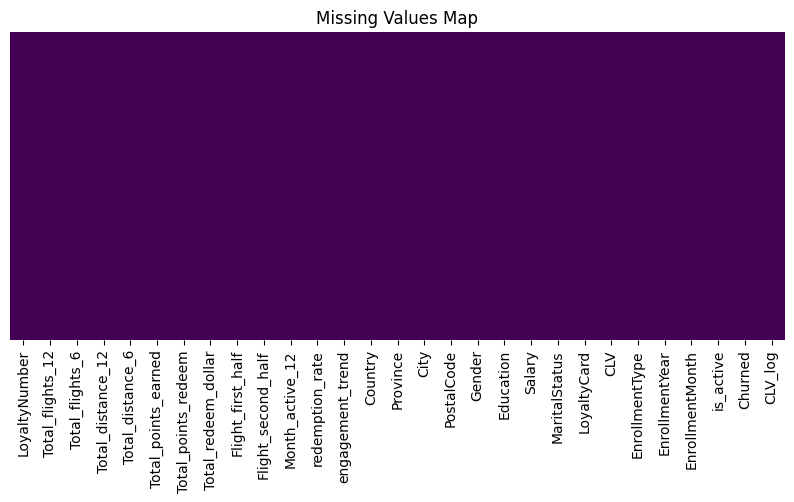

In [11]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Map")
plt.show()

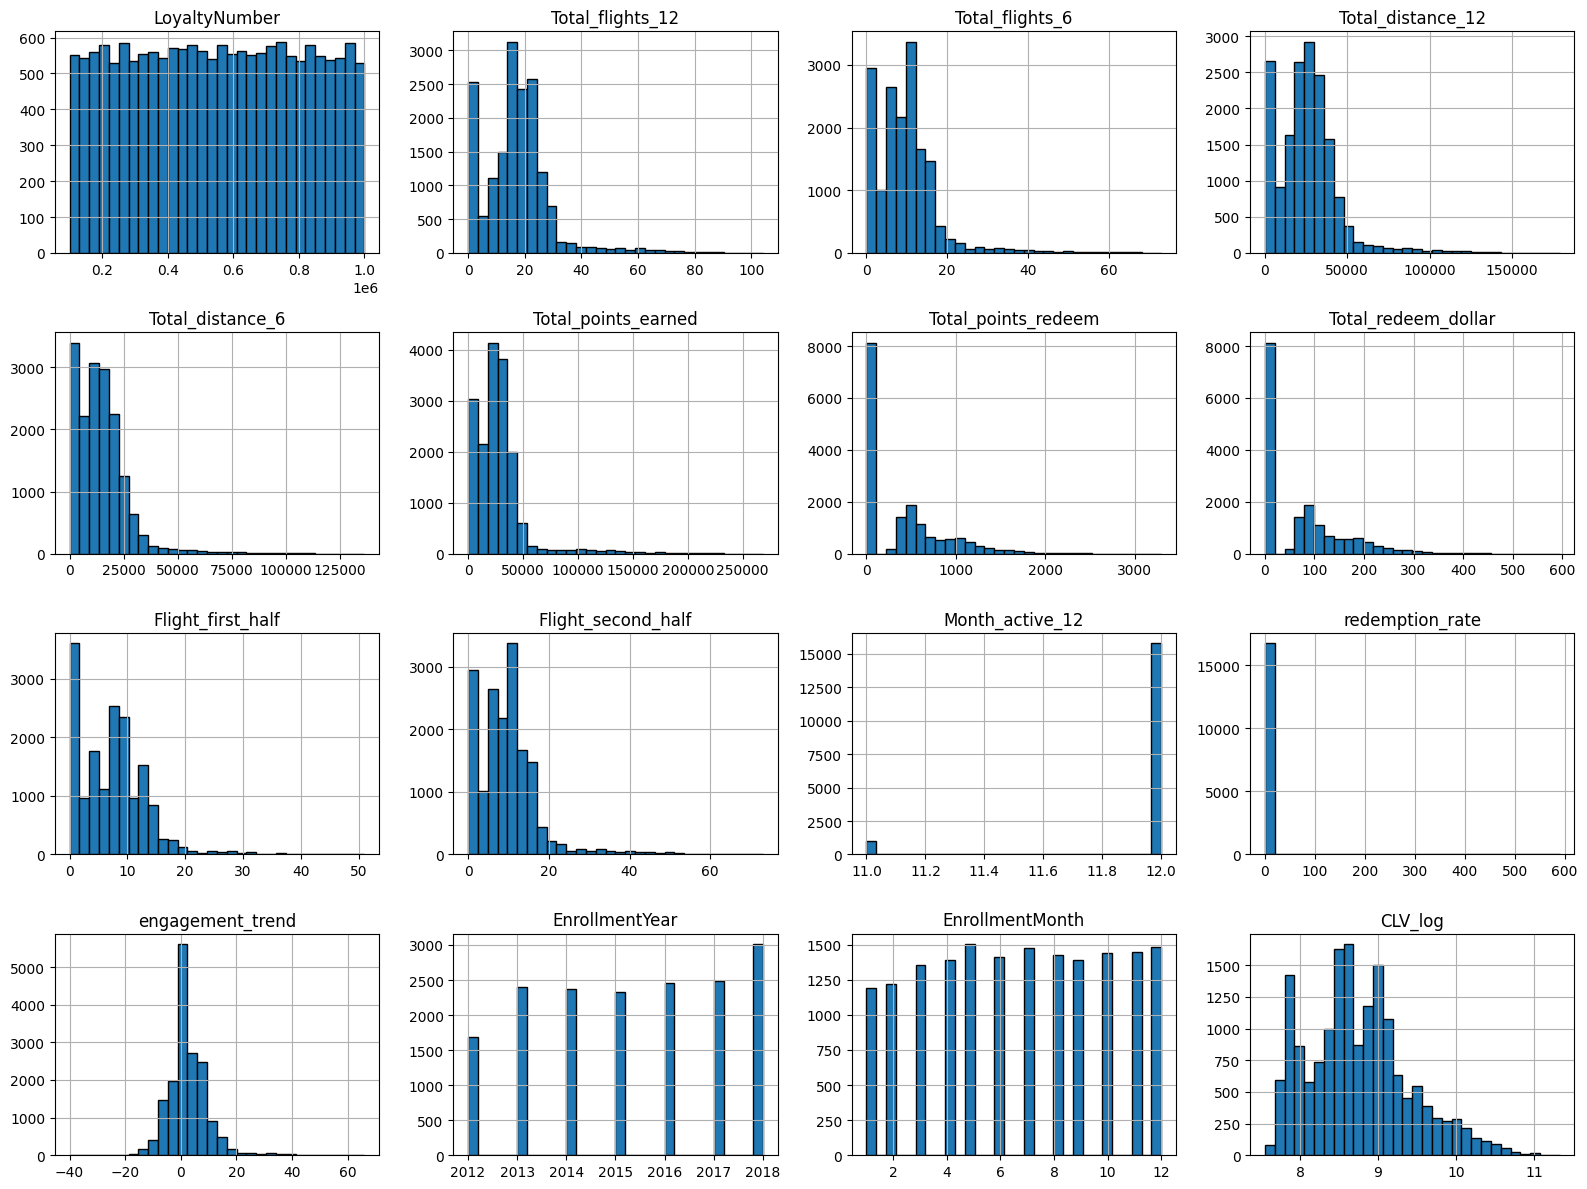

In [12]:
# Plot histograms for all numeric columns
df.select_dtypes(include=[np.number]).hist(figsize=(16, 12), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

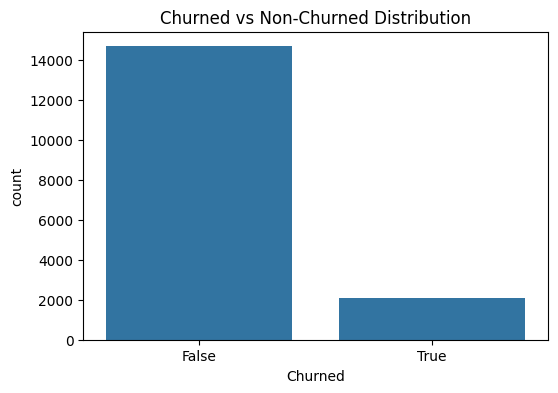

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churned')
plt.title("Churned vs Non-Churned Distribution")
plt.show()

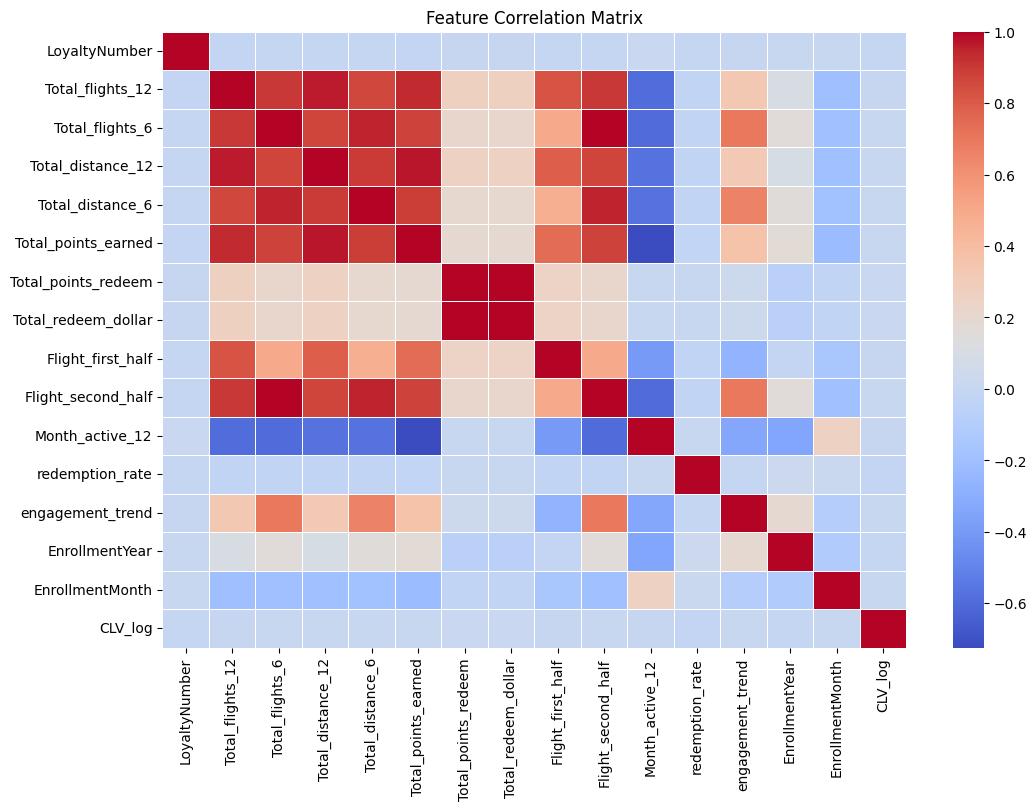

In [14]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

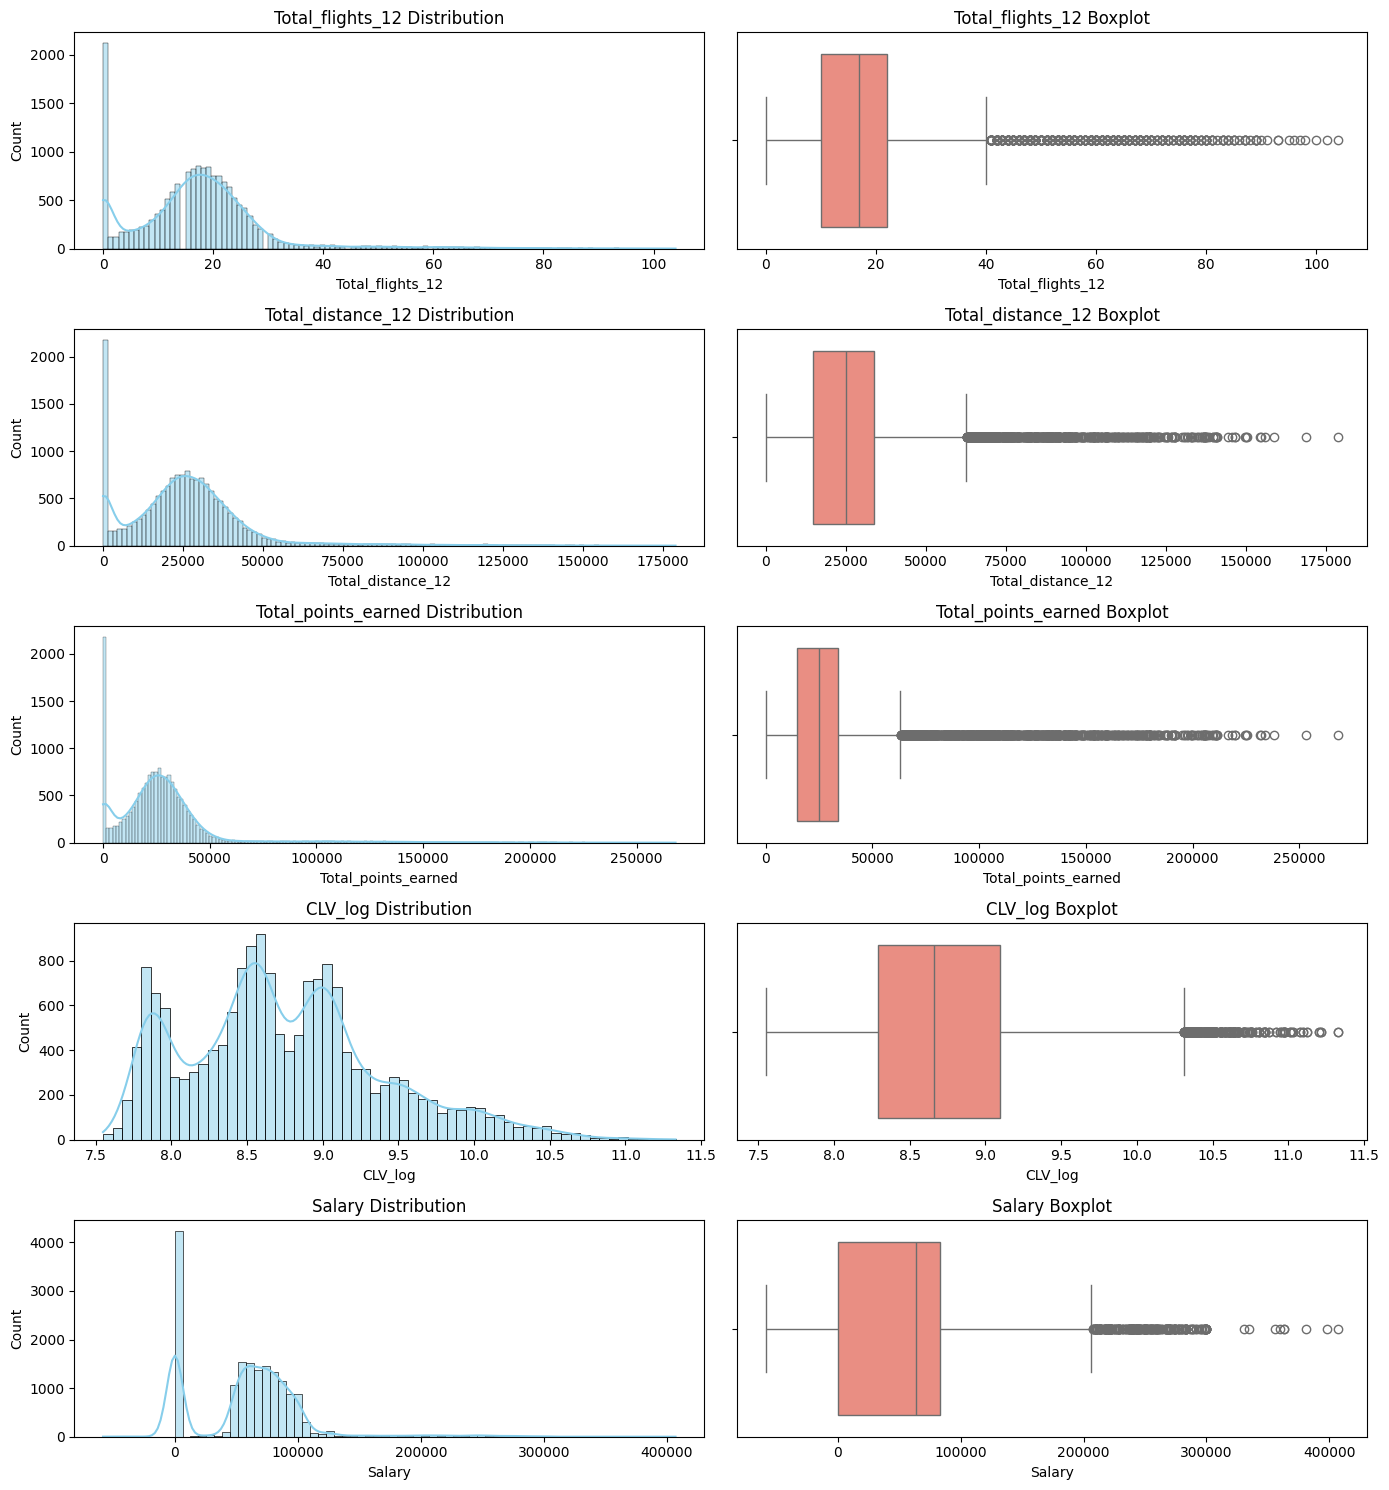

In [15]:
num_cols = ['Total_flights_12', 'Total_distance_12', 'Total_points_earned', 'CLV_log', 'Salary']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 3 * len(num_cols)))

for i, col in enumerate(num_cols):
    # Histogram / KDE distribution
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} Distribution')
    
    # Boxplot for outlier detection
    sns.boxplot(x=df[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

/tmp/ipykernel_26405/1405285842.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_26405/1405285842.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_26405/1405285842.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_26405/1405285842.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x`

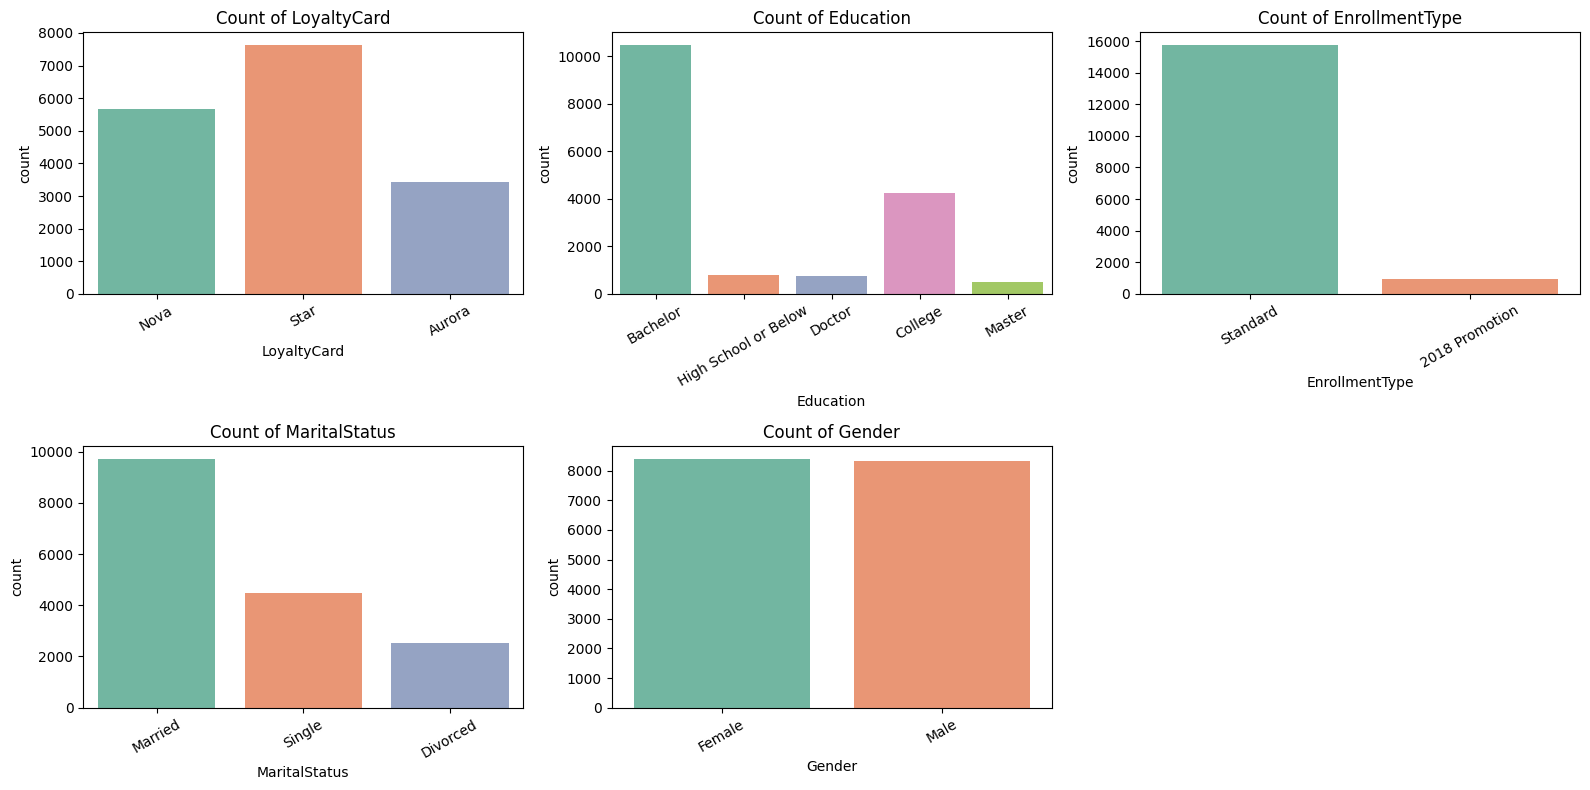

In [16]:
cat_cols = ['LoyaltyCard', 'Education', 'EnrollmentType', 'MaritalStatus', 'Gender']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Count of {col}')
    axes[i].tick_params(axis='x', rotation=30)

# Remove empty subplot space
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

/tmp/ipykernel_26405/83961181.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churned', y=col, ax=axes[i], palette='Set1')
/tmp/ipykernel_26405/83961181.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churned', y=col, ax=axes[i], palette='Set1')
/tmp/ipykernel_26405/83961181.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churned', y=col, ax=axes[i], palette='Set1')
/tmp/ipykernel_26405/83961181.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

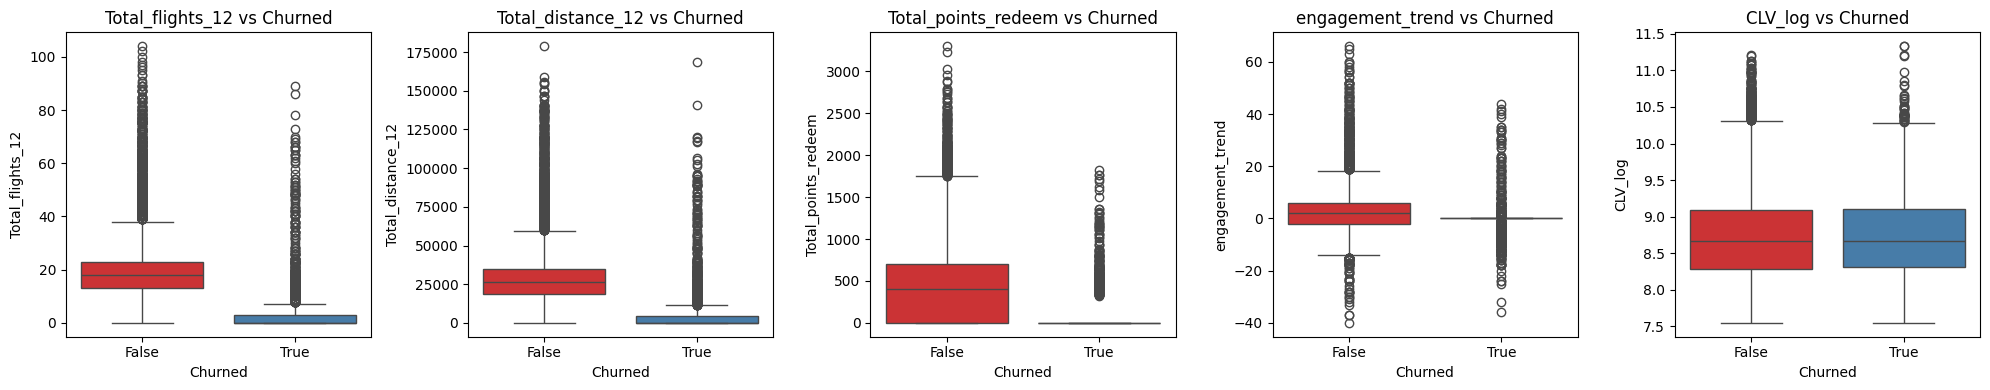

In [17]:
num_features = ['Total_flights_12', 'Total_distance_12', 'Total_points_redeem', 'engagement_trend', 'CLV_log']

fig, axes = plt.subplots(1, len(num_features), figsize=(20, 4))

for i, col in enumerate(num_features):
    sns.boxplot(data=df, x='Churned', y=col, ax=axes[i], palette='Set1')
    axes[i].set_title(f'{col} vs Churned')

plt.tight_layout()
plt.show()

/tmp/ipykernel_26405/2981194814.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate, x=col, y='Churned', ax=axes[i], palette='viridis')
/tmp/ipykernel_26405/2981194814.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate, x=col, y='Churned', ax=axes[i], palette='viridis')
/tmp/ipykernel_26405/2981194814.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate, x=col, y='Churned', ax=axes[i], palette='viridis')
/tmp/ipykernel_26405/2981194814.py:10: FutureWarning: 

Passing `palette` without assign

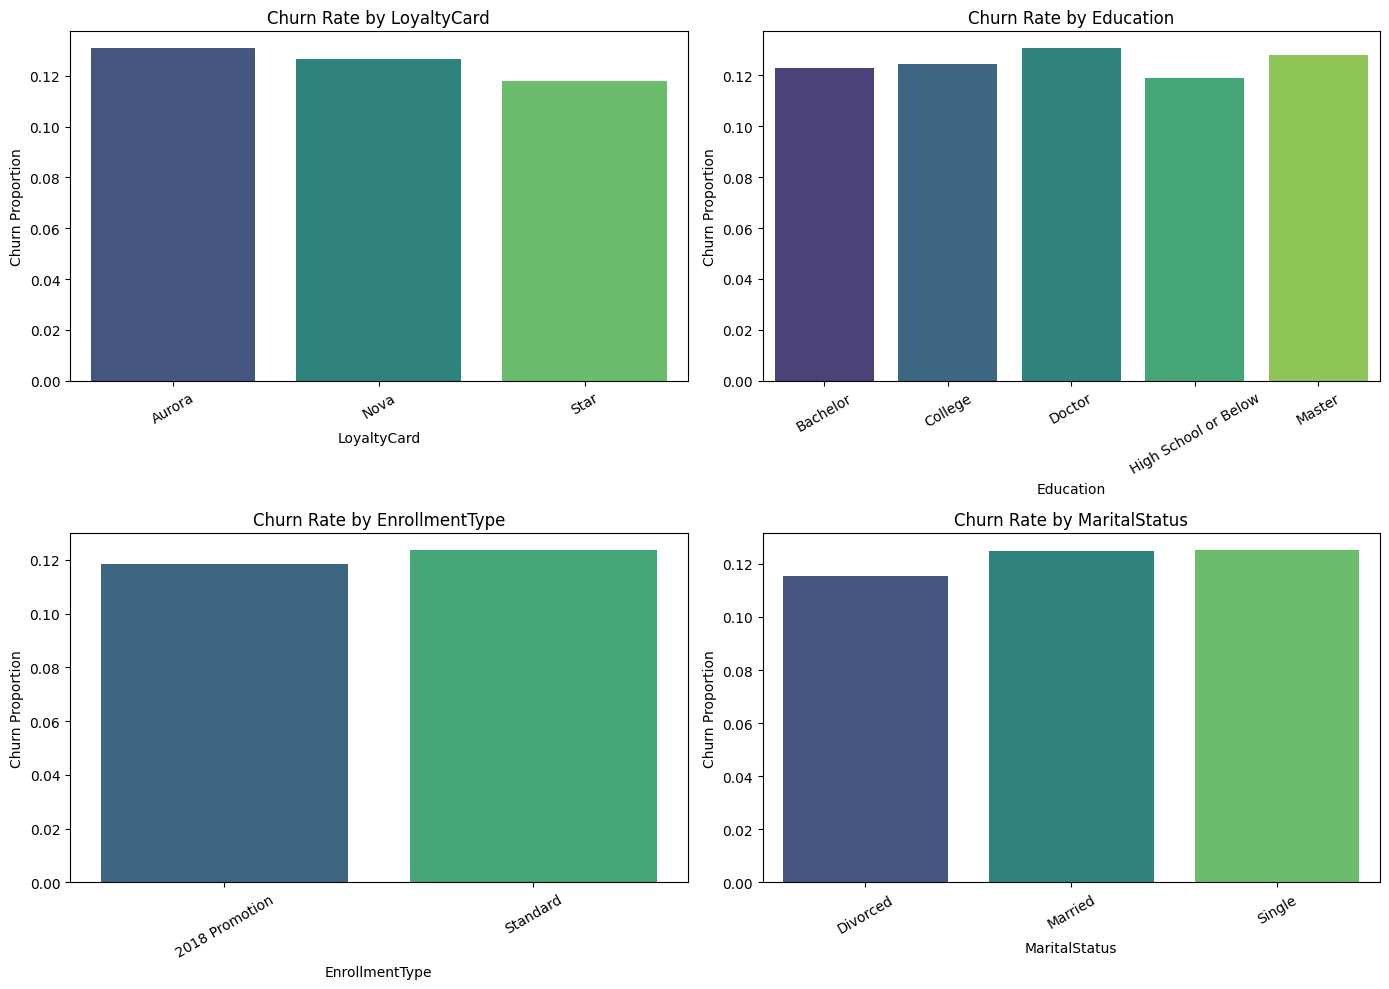

In [18]:
cat_features = ['LoyaltyCard', 'Education', 'EnrollmentType', 'MaritalStatus']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # Percentage churn rate by category group
    churn_rate = df.groupby(col)['Churned'].mean().reset_index()
    
    sns.barplot(data=churn_rate, x=col, y='Churned', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Proportion')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

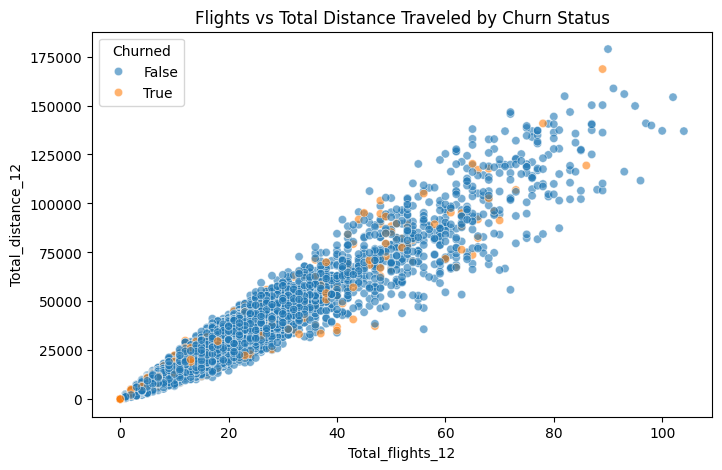

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Total_flights_12', y='Total_distance_12', hue='Churned', alpha=0.6)
plt.title("Flights vs Total Distance Traveled by Churn Status")
plt.show()

,LoyaltyCard,total_customers,churn_rate,avg_flights,avg_distance
0,Aurora,3429,0.130942,17.176145,26025.071158
1,Nova,5671,0.126433,17.150414,25751.722095
2,Star,7637,0.117978,16.942386,25306.800052


/tmp/ipykernel_26405/3280254829.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loyalty_summary, x='LoyaltyCard', y='churn_rate', palette='viridis')
/tmp/ipykernel_26405/3280254829.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loyalty_summary, x='LoyaltyCard', y='avg_flights', palette='magma')


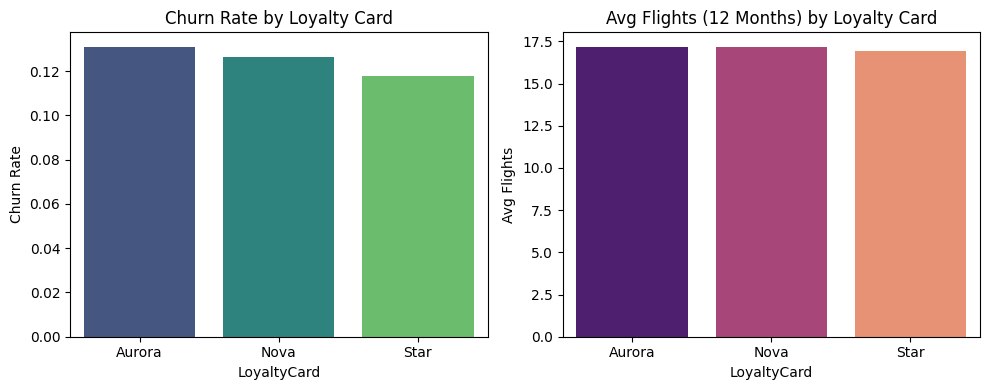

In [20]:
# Group by LoyaltyCard and calculate mean churn rate & average flights
loyalty_summary = df.groupby('LoyaltyCard').agg(
    total_customers=('LoyaltyNumber', 'count'),
    churn_rate=('Churned', 'mean'),
    avg_flights=('Total_flights_12', 'mean'),
    avg_distance=('Total_distance_12', 'mean')
).reset_index()

display(loyalty_summary)

# Visualization
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.barplot(data=loyalty_summary, x='LoyaltyCard', y='churn_rate', palette='viridis')
plt.title('Churn Rate by Loyalty Card')
plt.ylabel('Churn Rate')

plt.subplot(1, 2, 2)
sns.barplot(data=loyalty_summary, x='LoyaltyCard', y='avg_flights', palette='magma')
plt.title('Avg Flights (12 Months) by Loyalty Card')
plt.ylabel('Avg Flights')

plt.tight_layout()
plt.show()

MaritalStatus,Divorced,Married,Single
Education,,,
Bachelor,0.116788,0.121625,0.133217
College,0.117021,0.134401,0.119538
Doctor,0.132597,0.123377,0.164835
High School or Below,0.112000,0.127660,0.092857
Master,0.088542,0.158654,0.138889


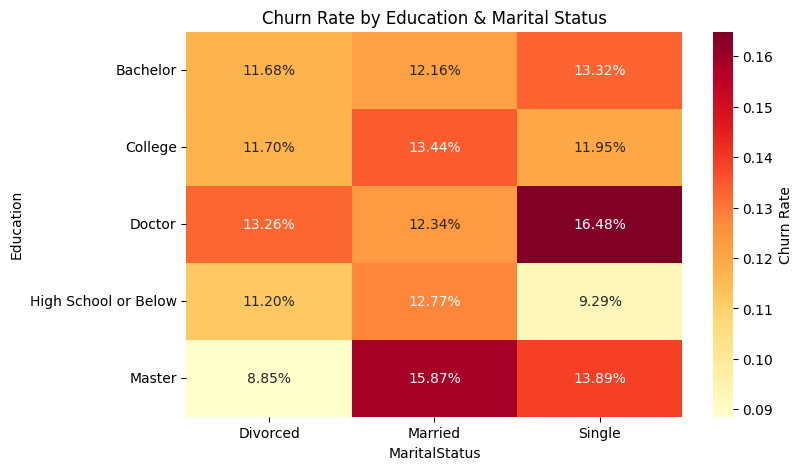

In [21]:
# Pivot table: Education vs MaritalStatus showing Churn Rate
edu_marital_churn = df.groupby(['Education', 'MaritalStatus'])['Churned'].mean().unstack()

display(edu_marital_churn)

# Heatmap Visualization
plt.figure(figsize=(8, 5))
sns.heatmap(edu_marital_churn, annot=True, fmt='.2%', cmap='YlOrRd', cbar_kws={'label': 'Churn Rate'})
plt.title('Churn Rate by Education & Marital Status')
plt.show()

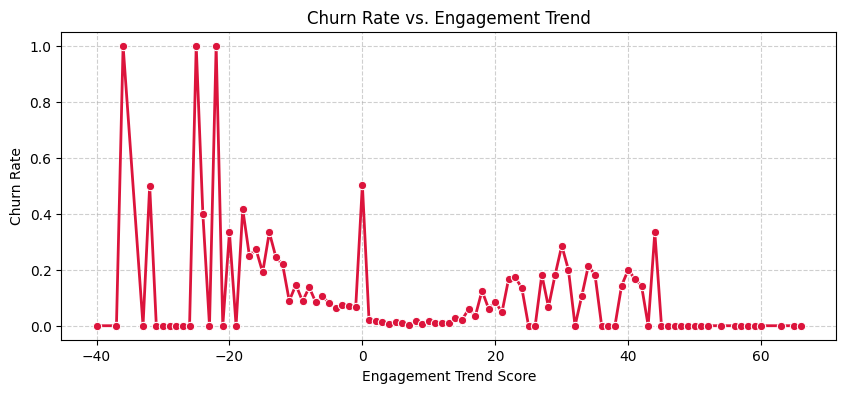

In [22]:
# Group by engagement trend
trend_summary = df.groupby('engagement_trend').agg(
    customer_count=('LoyaltyNumber', 'count'),
    churn_rate=('Churned', 'mean'),
    avg_points_redeemed=('Total_points_redeem', 'mean')
).reset_index()

# Visualization: Churn Rate across Engagement Trend
plt.figure(figsize=(10, 4))

sns.lineplot(data=trend_summary, x='engagement_trend', y='churn_rate', marker='o', color='crimson', linewidth=2)
plt.title('Churn Rate vs. Engagement Trend')
plt.xlabel('Engagement Trend Score')
plt.ylabel('Churn Rate')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

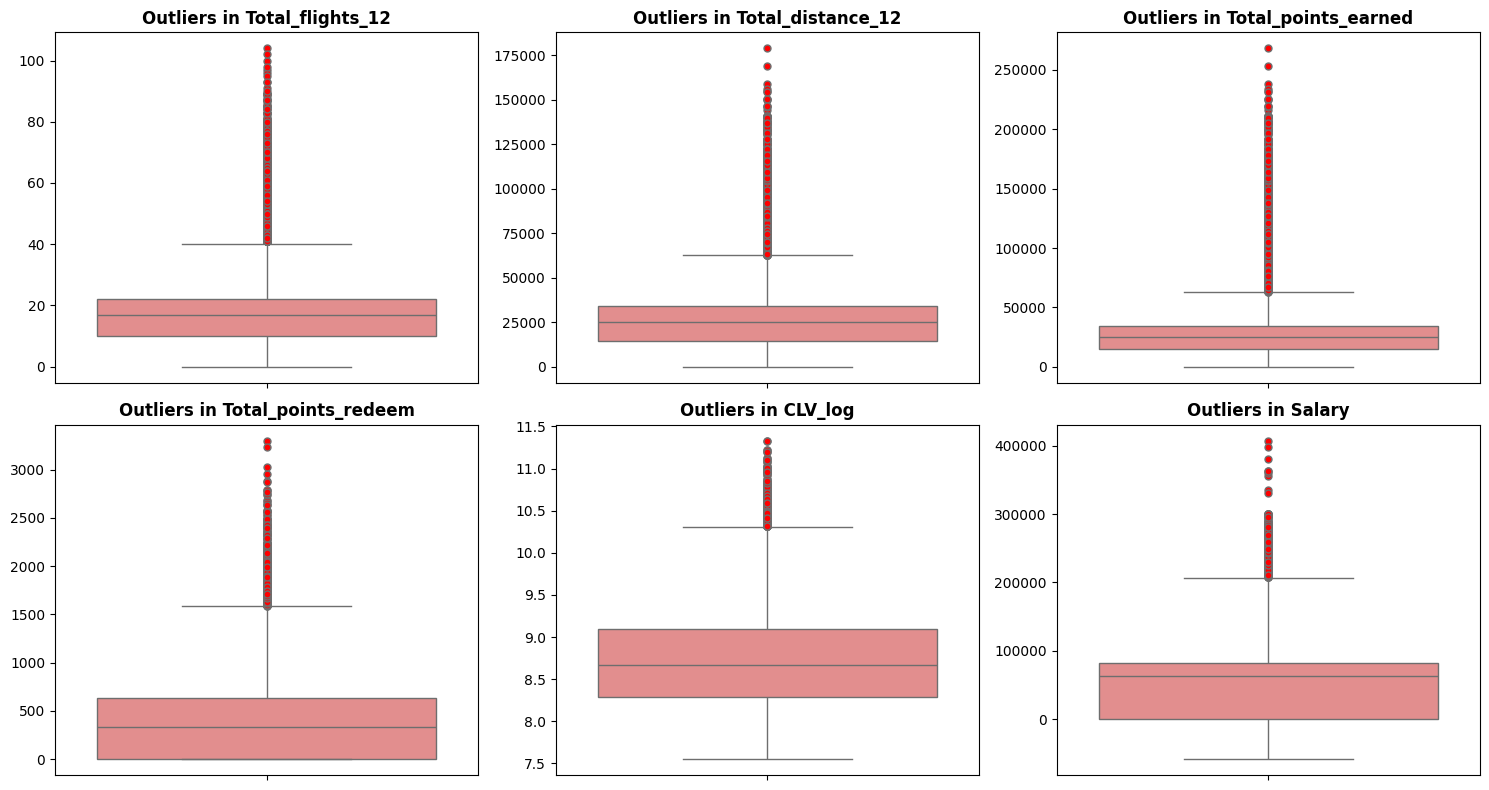

In [23]:
# Select key numerical features to inspect for outliers
outlier_cols = ['Total_flights_12', 'Total_distance_12', 'Total_points_earned', 'Total_points_redeem', 'CLV_log', 'Salary']

plt.figure(figsize=(15, 8))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='lightcoral', flierprops={"markerfacecolor": "red", "marker": "o", "markersize": 5})
    plt.title(f'Outliers in {col}', fontsize=12, fontweight='bold')
    plt.ylabel('')

plt.tight_layout()
plt.show()

/tmp/ipykernel_26405/2916465377.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churned', y=col, ax=axes[i], palette='Set2', flierprops={"markerfacecolor": "darkred", "markersize": 4})
/tmp/ipykernel_26405/2916465377.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churned', y=col, ax=axes[i], palette='Set2', flierprops={"markerfacecolor": "darkred", "markersize": 4})
/tmp/ipykernel_26405/2916465377.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churned', y=col, ax=axes[i], palette='Set2', flie

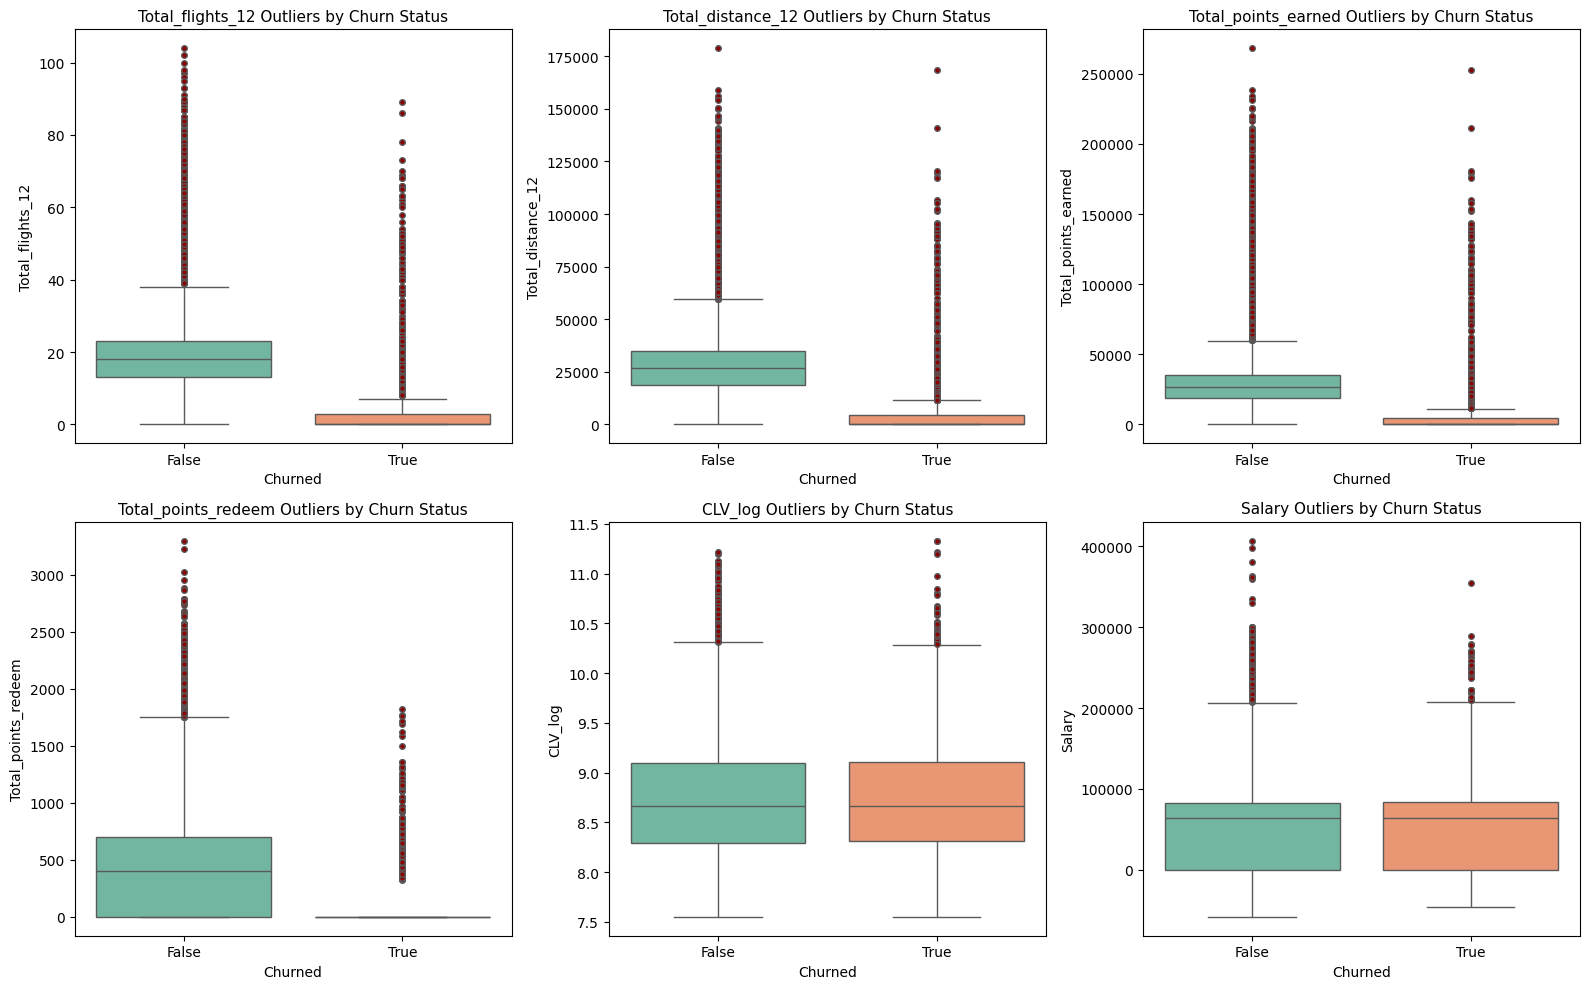

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    sns.boxplot(data=df, x='Churned', y=col, ax=axes[i], palette='Set2', flierprops={"markerfacecolor": "darkred", "markersize": 4})
    axes[i].set_title(f'{col} Outliers by Churn Status', fontsize=11)

plt.tight_layout()
plt.show()

In [25]:
# 1. Cast outlier columns to float to handle Decimal objects smoothly
for col in outlier_cols:
    df[col] = df[col].astype(float)

# 2. Calculate outlier count using IQR method
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df):.2%})")

Total_flights_12: 639 outliers (3.82%)
Total_distance_12: 602 outliers (3.60%)
Total_points_earned: 819 outliers (4.89%)
Total_points_redeem: 432 outliers (2.58%)
CLV_log: 332 outliers (1.98%)
Salary: 280 outliers (1.67%)


In [26]:
df_capped = df.copy()

# Set lower and upper percentile bounds (1.5% and 98.5%)
lower_pct = 0.015
upper_pct = 0.985

for col in outlier_cols:
    lower_bound = df_capped[col].quantile(lower_pct)
    upper_bound = df_capped[col].quantile(upper_pct)
    
    # Clip extreme values beyond the upper/lower percentiles
    df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)

print("Capping complete! Dataset shape preserved:", df_capped.shape)

Capping complete! Dataset shape preserved: (16737, 29)


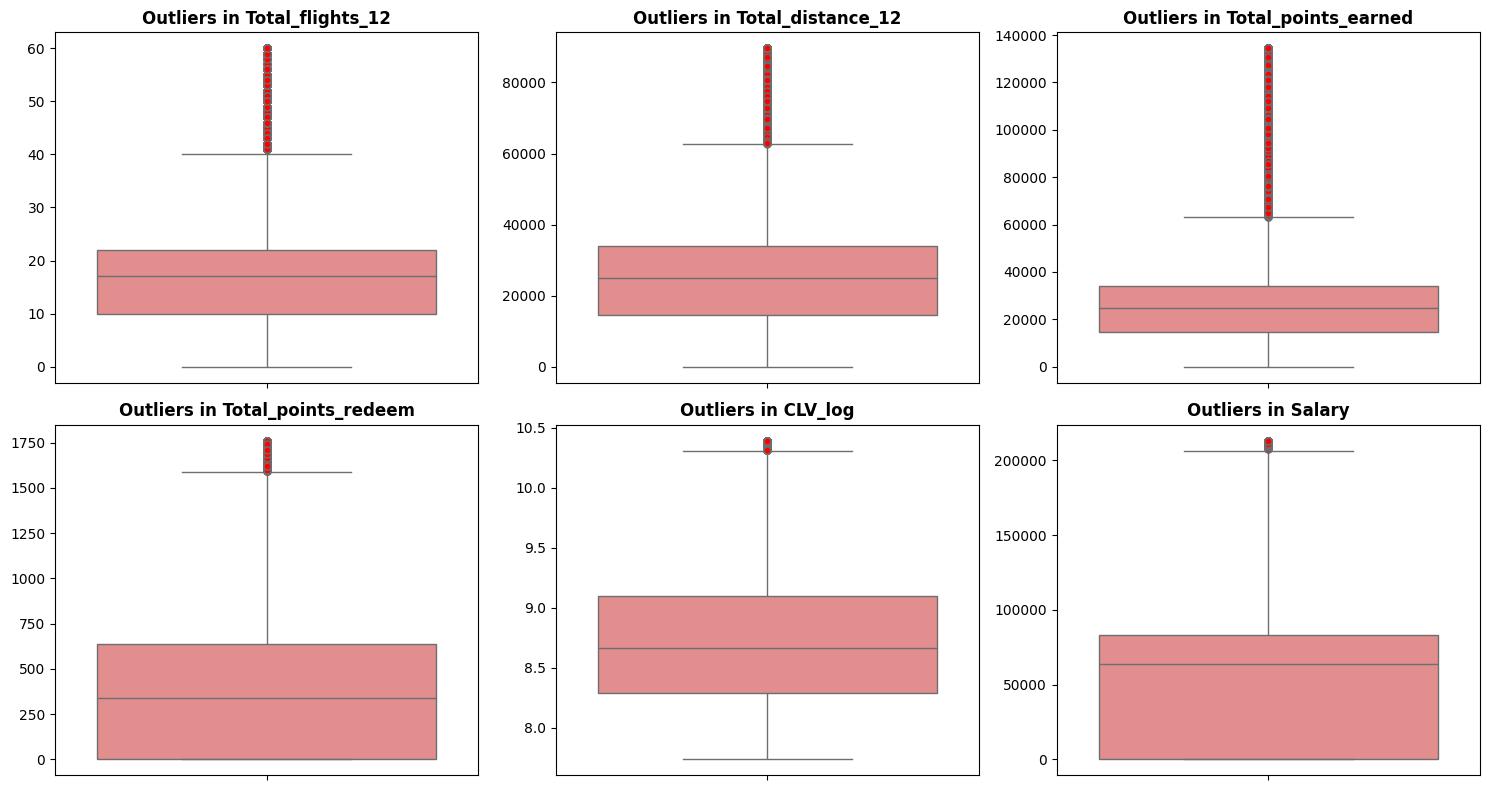

In [27]:
# Select key numerical features to inspect for outliers
outlier_cols = ['Total_flights_12', 'Total_distance_12', 'Total_points_earned', 'Total_points_redeem', 'CLV_log', 'Salary']

plt.figure(figsize=(15, 8))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_capped[col], color='lightcoral', flierprops={"markerfacecolor": "red", "marker": "o", "markersize": 5})
    plt.title(f'Outliers in {col}', fontsize=12, fontweight='bold')
    plt.ylabel('')

plt.tight_layout()
plt.show()

/tmp/ipykernel_26405/2586029220.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_capped, x='Churned', y=col, ax=axes[i], palette='Set2', flierprops={"markerfacecolor": "darkred", "markersize": 4})
/tmp/ipykernel_26405/2586029220.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_capped, x='Churned', y=col, ax=axes[i], palette='Set2', flierprops={"markerfacecolor": "darkred", "markersize": 4})
/tmp/ipykernel_26405/2586029220.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_capped, x='Churned', y=col, ax=axes[i],

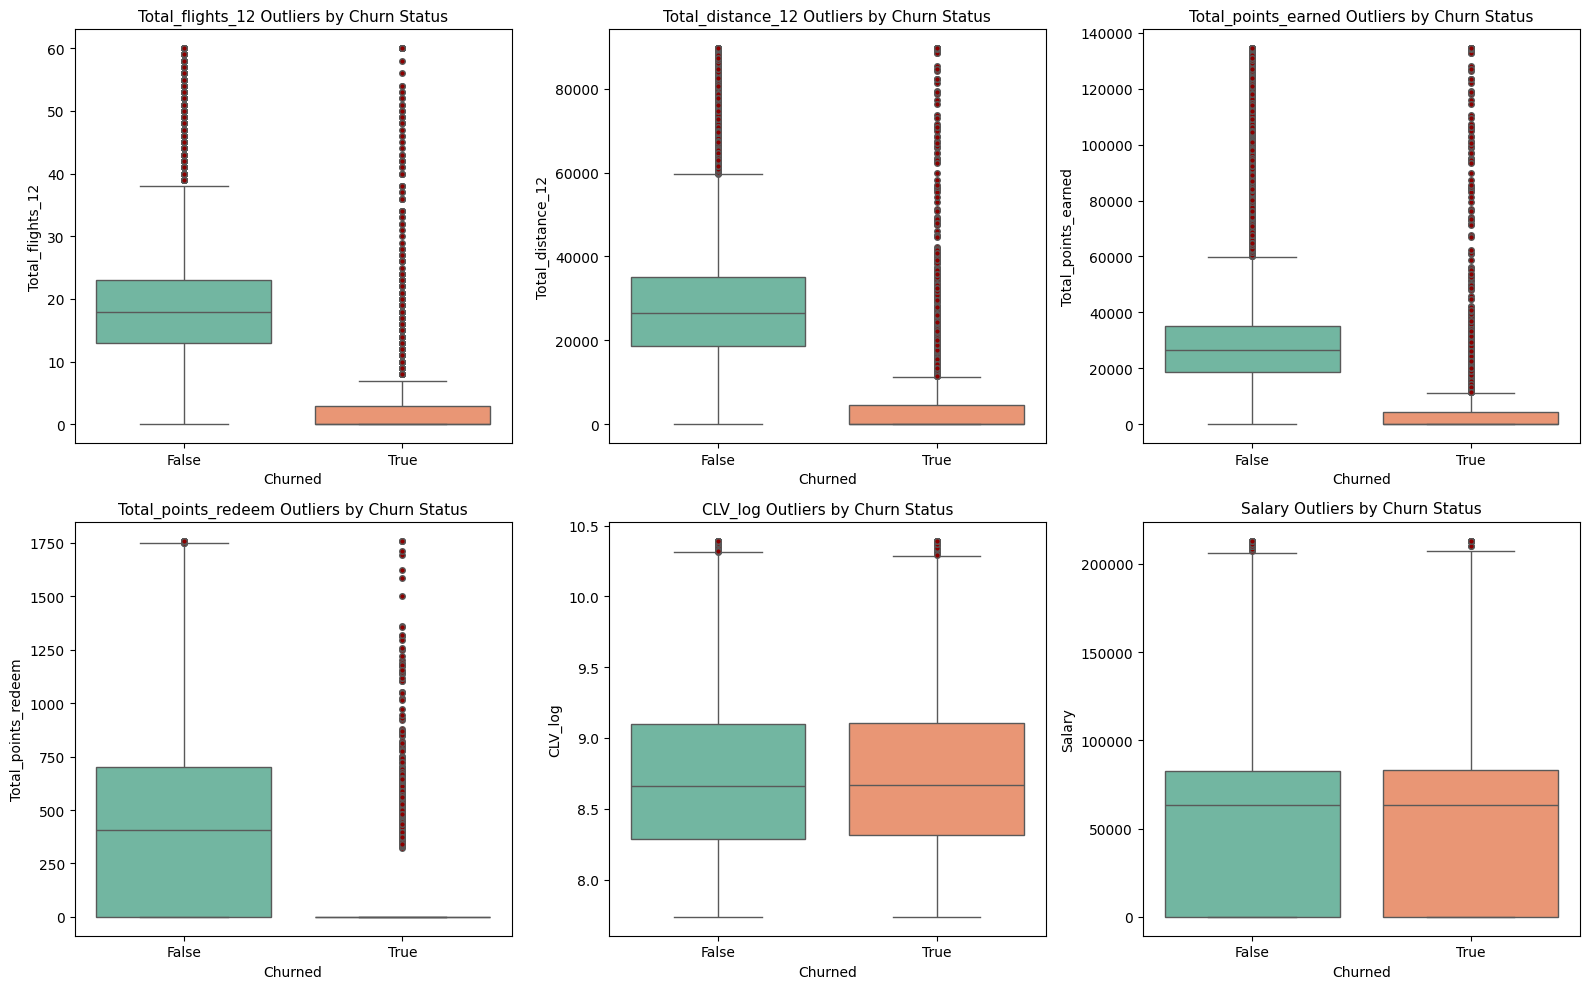

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    sns.boxplot(data=df_capped, x='Churned', y=col, ax=axes[i], palette='Set2', flierprops={"markerfacecolor": "darkred", "markersize": 4})
    axes[i].set_title(f'{col} Outliers by Churn Status', fontsize=11)

plt.tight_layout()
plt.show()

In [29]:
df_capped['Churned'].value_counts(normalize=True)

False    0.876501
True     0.123499
Name: Churned, dtype: float64

****Hypothesis Testing****

In [30]:
from scipy import stats

num_cols = ['Total_flights_12', 'Total_distance_12', 'Total_points_earned', 'Total_points_redeem', 'CLV_log', 'Salary']

print("--- Mann-Whitney U Test (Numerical Features vs Churned) ---")
for col in num_cols:
    churned_vals = df_capped[df_capped['Churned'] == True][col]
    retained_vals = df_capped[df_capped['Churned'] == False][col]
    
    stat, p_val = stats.mannwhitneyu(churned_vals, retained_vals)
    sig = "Significant" if p_val < 0.05 else "Not Significant"
    print(f"{col:20s} | U-Statistic: {stat:10.1f} | p-value: {p_val:.4e} ({sig})")

--- Mann-Whitney U Test (Numerical Features vs Churned) ---
Total_flights_12     | U-Statistic:  3516566.5 | p-value: 0.0000e+00 (Significant)
Total_distance_12    | U-Statistic:  3616965.5 | p-value: 0.0000e+00 (Significant)
Total_points_earned  | U-Statistic:  3734675.0 | p-value: 0.0000e+00 (Significant)
Total_points_redeem  | U-Statistic:  8057581.0 | p-value: 4.7655e-295 (Significant)
CLV_log              | U-Statistic: 15291283.5 | p-value: 5.2782e-01 (Not Significant)
Salary               | U-Statistic: 15142705.5 | p-value: 9.2680e-01 (Not Significant)


1. Conclusion: Active engagement in flight volume and distance is the strongest negative predictor of churn. Customers who fly less or stop flying in the past 12 months are significantly more likely to churn.
2. Conclusion: Customers actively earning and redeeming points are heavily locked into the loyalty ecosystem and rarely churn.

In [31]:
cat_cols = ['LoyaltyCard', 'Education', 'EnrollmentType', 'MaritalStatus', 'Gender']

print("\n--- Chi-Square Test (Categorical Features vs Churned) ---")
for col in cat_cols:
    contingency_table = pd.crosstab(df_capped[col], df_capped['Churned'])
    chi2, p_val, dof, _ = stats.chi2_contingency(contingency_table)
    sig = "Significant" if p_val < 0.05 else "Not Significant"
    print(f"{col:20s} | Chi2: {chi2:8.2f} | p-value: {p_val:.4e} ({sig})")


--- Chi-Square Test (Categorical Features vs Churned) ---
LoyaltyCard          | Chi2:     4.36 | p-value: 1.1326e-01 (Not Significant)
Education            | Chi2:     0.68 | p-value: 9.5320e-01 (Not Significant)
EnrollmentType       | Chi2:     0.20 | p-value: 6.5709e-01 (Not Significant)
MaritalStatus        | Chi2:     1.73 | p-value: 4.2031e-01 (Not Significant)
Gender               | Chi2:     0.56 | p-value: 4.5571e-01 (Not Significant)


1. Conclusion: Demographic attributes do not drive customer churn decisions in this dataset.
2. Conclusion: High-income or high-CLV customers churn at almost the exact same rate as lower-income/CLV customers.

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select numeric features
X_numeric = df_capped[num_cols].dropna()

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i) for i in range(len(X_numeric.columns))]

print("--- Variance Inflation Factor (VIF) ---")
print(vif_data)

--- Variance Inflation Factor (VIF) ---
               feature        VIF
0     Total_flights_12  46.097771
1    Total_distance_12  72.651263
2  Total_points_earned  36.488014
3  Total_points_redeem   1.970177
4              CLV_log   5.900382
5               Salary   2.835837


There is high Multicollinearity in Total_Distance_12, Total_Flight_12, Points Earned

In [33]:
from scipy.stats import pointbiserialr

print("--- Point-Biserial Correlation with Churned ---")
for col in num_cols + ['engagement_trend']:
    corr, p_val = pointbiserialr(df_capped['Churned'], df_capped[col])
    print(f"{col:20s} | Correlation: {corr:7.4f} | p-value: {p_val:.4e}")

--- Point-Biserial Correlation with Churned ---
Total_flights_12     | Correlation: -0.4059 | p-value: 0.0000e+00
Total_distance_12    | Correlation: -0.3953 | p-value: 0.0000e+00
Total_points_earned  | Correlation: -0.2992 | p-value: 0.0000e+00
Total_points_redeem  | Correlation: -0.2559 | p-value: 2.0885e-248
CLV_log              | Correlation:  0.0071 | p-value: 3.5953e-01
Salary               | Correlation: -0.0011 | p-value: 8.8888e-01
engagement_trend     | Correlation: -0.1384 | p-value: 2.5835e-72


Conclusion: Active flight engagement and points earning/redemption strongly decrease churn probability. Static customer attributes like salary and lifetime value have no linear relationship with churn.

In [34]:
print("--- Kolmogorov-Smirnov Test (Distribution Separation) ---")
for col in num_cols:
    churned_vals = df_capped[df_capped['Churned'] == True][col]
    retained_vals = df_capped[df_capped['Churned'] == False][col]
    
    ks_stat, p_val = stats.ks_2samp(churned_vals, retained_vals)
    print(f"{col:20s} | KS-Statistic: {ks_stat:.4f} | p-value: {p_val:.4e}")

--- Kolmogorov-Smirnov Test (Distribution Separation) ---
Total_flights_12     | KS-Statistic: 0.6991 | p-value: 0.0000e+00
Total_distance_12    | KS-Statistic: 0.6975 | p-value: 0.0000e+00
Total_points_earned  | KS-Statistic: 0.6971 | p-value: 0.0000e+00
Total_points_redeem  | KS-Statistic: 0.4596 | p-value: 0.0000e+00
CLV_log              | KS-Statistic: 0.0168 | p-value: 6.7787e-01
Salary               | KS-Statistic: 0.0114 | p-value: 9.7114e-01


1. Conclusion: A KS score close to 0.70 indicates massive predictive separation power. These top activity variables will serve as the primary drivers and split nodes for your classification models.

In [35]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

print("--- Cramér's V (Association Strength with Churned) ---")
for col in cat_cols:
    v_score = cramers_v(df_capped[col], df_capped['Churned'])
    print(f"{col:20s} | Cramér's V: {v_score:.4f}")

--- Cramér's V (Association Strength with Churned) ---
LoyaltyCard          | Cramér's V: 0.0119
Education            | Cramér's V: 0.0000
EnrollmentType       | Cramér's V: 0.0000
MaritalStatus        | Cramér's V: 0.0000
Gender               | Cramér's V: 0.0000


There is no association of strength between categorical variables

In [36]:
danger_cols_to_drop = [
    # Category 1: Leakage & IDs
    'is_active', 'LoyaltyNumber', 'PostalCode', 'City', 'Province', 'Country', 'CLV',
    
    # Category 2: Statistically Insignificant Categoricals & High-VIF/Low-Signal Features
    'Education', 'MaritalStatus', 'Gender', 'EnrollmentType', 'Salary', 'CLV_log'
]

X = df_capped.drop(columns=danger_cols_to_drop + ['Churned'])
y = df_capped['Churned']

In [37]:
from sklearn.model_selection import train_test_split

# Map LoyaltyCard to ordinal numeric values
card_map = {'Star': 1, 'Nova': 2, 'Aurora': 3}
X['LoyaltyCard'] = X['LoyaltyCard'].map(card_map)

# Perform stratified train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train Churn Rate: {y_train.mean():.2%}, Test Churn Rate: {y_test.mean():.2%}")

Training shape: (13389, 15), Test shape: (3348, 15)
Train Churn Rate: 12.35%, Test Churn Rate: 12.34%


In [38]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [39]:
%pip install "scipy<1.12.0" "numpy<2.0.0" "imbalanced-learn==0.12.0"

  Using cached imbalanced_learn-0.12.0-py3-none-any.whl.metadata (8.2 kB)
Using cached imbalanced_learn-0.12.0-py3-none-any.whl (257 kB)
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.2
    Uninstalling imbalanced-learn-0.14.2:
      Successfully uninstalled imbalanced-learn-0.14.2
Note: you may need to restart the kernel to use updated packages.


In [40]:
%pip install "imbalanced-learn>=0.12.3"

  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
Using cached imbalanced_learn-0.14.2-py3-none-any.whl (236 kB)
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.12.0
    Uninstalling imbalanced-learn-0.12.0:
      Successfully uninstalled imbalanced-learn-0.12.0
Note: you may need to restart the kernel to use updated packages.


In [41]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {y_train_smote.value_counts().to_dict()}")

Before SMOTE: {False: 11735, True: 1654}
After SMOTE:  {False: 11735, True: 11735}


**Model Building**

In [42]:
!pip install mlflow

In [43]:
%pip install "mlflow>=2.12.0,<2.14.0"

Note: you may need to restart the kernel to use updated packages.


In [44]:
%pip install --force-reinstall "numpy==1.26.4" "scipy==1.11.4" "xgboost>=1.7.0,<2.0.0" "imbalanced-learn>=0.12.3"

  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.11.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached xgboost-1.7.6-py3-none-manylinux2014_x86_64.whl.metadata (1.9 kB)
  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached sklearn_compat-0.1.6-py3-none-any.whl.metadata (22 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
Using cached scipy-1.11.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (36.4 MB)
Using cached xgboost-1.7.6-py3-none-manylinux2014_x86_64.whl (200.3 MB)
Using cached imbalanced_learn-0.14.2-py3-none-any.whl (236 kB)


In [45]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, recall_score, f1_score, precision_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Set MLflow experiment name
mlflow.set_experiment("churn_prediction_experiment")

vif_drop = ['Total_distance_12', 'Total_points_earned']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'f1', 'recall', 'precision', 'accuracy']

# ==============================================================================
# RUN 1: Logistic Regression (Dataset A: Filtered / No Nominal Categoricals)
# ==============================================================================
with mlflow.start_run(run_name="Logistic_Regression_Dataset_A"):
    # 1. Feature Prep
    X_train_lr_A = X_train.drop(columns=vif_drop)
    X_test_lr_A = X_test.drop(columns=vif_drop)

    # 2. Pipeline Definition
    lr_pipeline_A = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ])

    # 3. Log Parameters
    mlflow.log_params({
        "model_type": "LogisticRegression",
        "dataset_version": "Dataset A (No Nominal Categoricals)",
        "smote_random_state": 42,
        "max_iter": 1000,
        "cv_folds": 5
    })

    # 4. Cross Validation & Tracking
    cv_results_A = cross_validate(lr_pipeline_A, X_train_lr_A, y_train, cv=cv, scoring=scoring)
    
    mlflow.log_metrics({
        "cv_mean_roc_auc": cv_results_A['test_roc_auc'].mean(),
        "cv_std_roc_auc": cv_results_A['test_roc_auc'].std(),
        "cv_mean_recall": cv_results_A['test_recall'].mean(),
        "cv_mean_f1": cv_results_A['test_f1'].mean(),
        "cv_mean_accuracy": cv_results_A['test_accuracy'].mean()
    })

    # 5. Full Fit & Test Set Evaluation
    lr_pipeline_A.fit(X_train_lr_A, y_train)
    y_pred_A = lr_pipeline_A.predict(X_test_lr_A)
    y_proba_A = lr_pipeline_A.predict_proba(X_test_lr_A)[:, 1]

    mlflow.log_metrics({
        "test_roc_auc": roc_auc_score(y_test, y_proba_A),
        "test_accuracy": accuracy_score(y_test, y_pred_A),
        "test_recall": recall_score(y_test, y_pred_A),
        "test_precision": precision_score(y_test, y_pred_A),
        "test_f1": f1_score(y_test, y_pred_A)
    })

    # 6. Log Model Artifact
    mlflow.sklearn.log_model(lr_pipeline_A, "model")
    print("✅ Completed Run 1: Logistic Regression (Dataset A)")


# ==============================================================================
# RUN 2: XGBoost (Dataset B: Full Categoricals Included)
# ==============================================================================
with mlflow.start_run(run_name="XGBoost_Dataset_B"):
    # 1. Dataset B Prep
    danger_cols_B = ['is_active', 'LoyaltyNumber', 'PostalCode', 'City', 'Province', 'Country', 'CLV', 'Salary', 'CLV_log']
    X_B = df_capped.drop(columns=danger_cols_B + ['Churned'])
    y_B = df_capped['Churned']

    X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
        X_B, y_B, test_size=0.20, random_state=42, stratify=y_B
    )

    cat_cols_B = ['Education', 'MaritalStatus', 'Gender', 'EnrollmentType', 'LoyaltyCard']

    preprocessor_xgb = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_B)
    ], remainder='passthrough')

    # 2. Pipeline Definition
    xgb_pipeline_B = ImbPipeline([
        ('prep', preprocessor_xgb),
        ('smote', SMOTE(random_state=42)),
        ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss'))
    ])

    # 3. Log Parameters
    mlflow.log_params({
        "model_type": "XGBoost",
        "dataset_version": "Dataset B (Full Categoricals One-Hot)",
        "n_estimators": 100,
        "learning_rate": 0.1,
        "eval_metric": "logloss",
        "smote_random_state": 42
    })

    # 4. Fit & Test Set Evaluation
    xgb_pipeline_B.fit(X_train_B, y_train_B)
    y_pred_xgb_B = xgb_pipeline_B.predict(X_test_B)
    y_proba_xgb_B = xgb_pipeline_B.predict_proba(X_test_B)[:, 1]

    mlflow.log_metrics({
        "test_roc_auc": roc_auc_score(y_test_B, y_proba_xgb_B),
        "test_accuracy": accuracy_score(y_test_B, y_pred_xgb_B),
        "test_recall": recall_score(y_test_B, y_pred_xgb_B),
        "test_precision": precision_score(y_test_B, y_pred_xgb_B),
        "test_f1": f1_score(y_test_B, y_pred_xgb_B)
    })

    # 5. Log Model Artifact
    mlflow.sklearn.log_model(xgb_pipeline_B, "model")
    print("✅ Completed Run 2: XGBoost (Dataset B)")

2026/07/24 14:16:42 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpqxblxpjz/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==1.6.0']. Set logging level to DEBUG to see the full traceback. 
Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x72f8a33e0ee0>
Traceback (most recent call last):
  File "/anaconda/envs/azureml_py38/lib/python3.10/site-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/anaconda/envs/azureml_py38/lib/python3.10/site-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
  File "/anaconda/envs/azureml_py38/lib/python3.10/site-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTL

✅ Completed Run 1: Logistic Regression (Dataset A)
✅ Completed Run 2: XGBoost (Dataset B)


,Model / Run Name,Test ROC-AUC,Test F1,Test Recall,Test Precision,Test Accuracy
0,Logistic_Regression_Dataset_A,0.912109,0.595458,0.857143,0.456186,0.856332
1,XGBoost_Dataset_B,0.966995,0.879064,0.818402,0.949438,0.972222
2,Logistic_Regression_Dataset_A,0.912109,0.595458,0.857143,0.456186,0.856332
3,Logistic_Regression_Dataset_A,0.912109,0.595458,0.857143,0.456186,0.856332
4,XGBoost_Dataset_B,0.966995,0.879064,0.818402,0.949438,0.972222


MetricLogistic Regression (Dataset A)XGBoost (Dataset B)WinnerTest ROC-AUC0.91210.9670XGBoost (+5.5%)Test F1-Score0.59550.8791XGBoost (+28.4%)Test Precision0.45620.9494XGBoost (+49.3%)Test Recall0.85710.8184Logistic Regression (+3.9%)Test Accuracy0.85630.9722XGBoost (+11.6%)

In [49]:
from azure.ai.ml import automl, Input
from azure.ai.ml.entities import Data
from azure.ai.ml.constants import AssetTypes

# 1. Prepare and save training dataset locally
X_train_B['Churned'] = y_train_B
X_train_B.to_csv("churn_train_automl.csv", index=False)

# 2. Register CSV as a formal Azure ML Data Asset
automl_data_asset = Data(
    path="churn_train_automl.csv",
    type=AssetTypes.URI_FILE,
    description="Training data for churn AutoML experiment",
    name="churn_train_automl_dataset",
    version="1"
)
registered_data = ml_client.data.create_or_update(automl_data_asset)
print(f"✅ Data Asset Registered: {registered_data.id}")

# 3. Configure AutoML Job using the Registered Data Asset
automl_job = automl.classification(
    compute="azuremlopscompute",
    experiment_name="churn_automl_experiment",
    training_data=Input(type=AssetTypes.URI_FILE, path=registered_data.id),
    target_column_name="Churned",
    primary_metric="AUC_weighted",
    n_cross_validations=5
)

# 4. Set Limits
automl_job.set_limits(
    timeout_minutes=30,
    max_trials=5,
    max_concurrent_trials=2
)

# 5. Submit Job to Azure ML
returned_job = ml_client.jobs.create_or_update(automl_job)
print(f"🚀 AutoML Job Submitted! Track progress here: {returned_job.studio_url}")

✅ Data Asset Registered: /subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resourceGroups/azuremlairline/providers/Microsoft.MachineLearningServices/workspaces/azuremlairlinemlops/data/churn_train_automl_dataset/versions/1
🚀 AutoML Job Submitted! Track progress here: https://ml.azure.com/runs/brave_cheetah_zxbp48z2g5?wsid=/subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resourcegroups/azuremlairline/workspaces/azuremlairlinemlops&tid=5ee697d5-e46c-46e4-b30c-d590dbaa142e


In [50]:
import mltable
from azure.ai.ml import automl, Input
from azure.ai.ml.entities import Data
from azure.ai.ml.constants import AssetTypes

# 1. Prepare and save training CSV locally
X_train_B['Churned'] = y_train_B
X_train_B.to_csv("churn_train_automl.csv", index=False)

# 2. Write an explicit MLTable specification file
mltable_content = """
paths:
  - file: ./churn_train_automl.csv
transformations:
  - read_delimited:
      delimiter: ','
      encoding: 'utf8'
      empty_as_string: false
"""
with open("MLTable", "w") as f:
    f.write(mltable_content)

# 3. Register the folder containing MLTable as an MLTABLE Data Asset
automl_data_asset = Data(
    path="./",
    type=AssetTypes.MLTABLE,
    description="MLTable training dataset for churn AutoML experiment",
    name="churn_train_mltable_dataset",
    version="1"
)
registered_mltable = ml_client.data.create_or_update(automl_data_asset)
print(f"✅ MLTable Data Asset Registered: {registered_mltable.id}")

# 4. Configure AutoML Job using the MLTable Asset
automl_job = automl.classification(
    compute="azuremlopscompute",
    experiment_name="churn_automl_experiment",
    training_data=Input(type=AssetTypes.MLTABLE, path=registered_mltable.id),
    target_column_name="Churned",
    primary_metric="AUC_weighted",
    n_cross_validations=5
)

# 5. Set Job Limits
automl_job.set_limits(
    timeout_minutes=30,
    max_trials=5,
    max_concurrent_trials=2
)

# 6. Submit Job to Azure ML
returned_job = ml_client.jobs.create_or_update(automl_job)
print(f"🚀 AutoML Job Successfully Submitted! Track progress: {returned_job.studio_url}")

Uploading sanjay.vk904 (3.35 MBs): 100%|██████████| 3346664/3346664 [00:01<00:00, 2002095.27it/s]




✅ MLTable Data Asset Registered: /subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resourceGroups/azuremlairline/providers/Microsoft.MachineLearningServices/workspaces/azuremlairlinemlops/data/churn_train_mltable_dataset/versions/1
🚀 AutoML Job Successfully Submitted! Track progress: https://ml.azure.com/runs/purple_crowd_1kgv4zg80h?wsid=/subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resourcegroups/azuremlairline/workspaces/azuremlairlinemlops&tid=5ee697d5-e46c-46e4-b30c-d590dbaa142e


In [51]:
# Register the MLflow model artifact to Azure ML Model Registry
model_uri = f"runs:/{runs.iloc[0]['run_id']}/model"
registered_model = mlflow.register_model(
    model_uri=model_uri,
    name="airline_churn_xgboost_model"
)

print(f"✅ Model registered successfully: {registered_model.name} (Version {registered_model.version})")

Successfully registered model 'airline_churn_xgboost_model'.
Created version '1' of model 'airline_churn_xgboost_model'.


/tmp/ipykernel_26405/1754835041.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='magma')


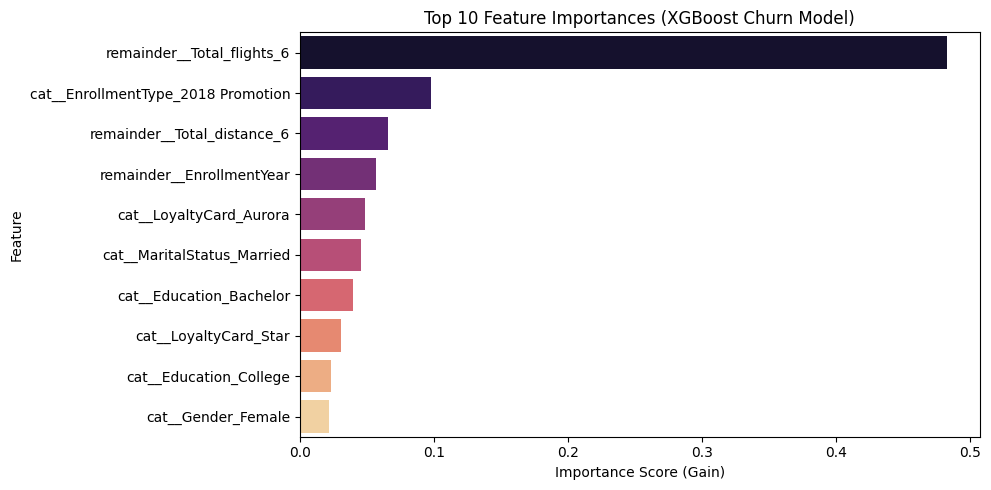

In [52]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Extract feature importances from the fitted XGBoost model inside the pipeline
xgb_model = xgb_pipeline_B.named_steps['classifier']
feature_names = xgb_pipeline_B.named_steps['prep'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot Top 10 Features
plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Feature Importances (XGBoost Churn Model)')
plt.xlabel('Importance Score (Gain)')
plt.tight_layout()
plt.show()

Test Inference

In [53]:
import pandas as pd

# Define a sample customer record (e.g., declining flight activity)
sample_customer = pd.DataFrame([{
    'Total_flights_12': 2,
    'Total_flights_6': 0,
    'Total_distance_12': 1800,
    'Total_distance_6': 0,
    'Total_points_earned': 1800,
    'Total_points_redeem': 0,
    'Total_redeem_dollar': 0,
    'Flight_first_half': 2,
    'Flight_second_half': 0,
    'Month_active_12': 2,
    'redemption_rate': 0.0,
    'engagement_trend': -2,
    'EnrollmentYear': 2017,
    'EnrollmentMonth': 4,
    'Education': 'Bachelor',
    'MaritalStatus': 'Married',
    'Gender': 'Female',
    'EnrollmentType': 'Standard',
    'LoyaltyCard': 'Star'
}])

# Predict using fitted XGBoost pipeline
predicted_class = xgb_pipeline_B.predict(sample_customer)[0]
churn_probability = xgb_pipeline_B.predict_proba(sample_customer)[0][1]

print(f"Prediction: {'⚠️ CHURN RISK' if predicted_class else '✅ RETAINED'}")
print(f"Churn Probability: {churn_probability:.2%}")

Prediction: ⚠️ CHURN RISK
Churn Probability: 99.02%


In [1]:
print('Completed')

Completed


In [3]:
from azure.ai.ml import MLClient, load_component
from azure.identity import DefaultAzureCredential

# 1. Connect to your Azure ML workspace
ml_client = MLClient.from_config(credential=DefaultAzureCredential())

# 2. Load the component definition with the full relative path
prep_component = load_component(source="./airline-churn-mlops/components/prep_data.yaml")
# 3. Register or update the component in your Azure ML Workspace
registered_component = ml_client.components.create_or_update(prep_component)
print(f"✅ Registered Component: {registered_component.name} (v{registered_component.version})")

Found the config file in: /config.json
Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Uploading components (0.0 MBs): 100%|██████████| 3221/3221 [00:01<00:00, 2979.32it/s]




✅ Registered Component: prep_data_component (v1)


In [4]:
# Load and register train_model component
train_component = load_component(source="./airline-churn-mlops/components/train_model.yaml")
registered_train_comp = ml_client.components.create_or_update(train_component)
print(f"✅ Registered Component: {registered_train_comp.name} (v{registered_train_comp.version})")

Uploading components (0.01 MBs): 100%|██████████| 5710/5710 [00:00<00:00, 6765.99it/s]




✅ Registered Component: train_model_component (v1)


In [5]:
# Load and register evaluate_model component
eval_component = load_component(source="./airline-churn-mlops/components/evaluate_model.yaml")
registered_eval_comp = ml_client.components.create_or_update(eval_component)
print(f"✅ Registered Component: {registered_eval_comp.name} (v{registered_eval_comp.version})")

Uploading components (0.01 MBs): 100%|██████████| 8551/8551 [00:00<00:00, 10221.14it/s]




✅ Registered Component: evaluate_model_component (v1)


In [6]:
from azure.ai.ml import load_component, Input
from azure.ai.ml.dsl import pipeline

# 1. Load component definitions
prep_comp = load_component(source="./airline-churn-mlops/components/prep_data.yaml")
train_comp = load_component(source="./airline-churn-mlops/components/train_model.yaml")
eval_comp = load_component(source="./airline-churn-mlops/components/evaluate_model.yaml")

# 2. Construct the pipeline graph
@pipeline(
    default_compute="azuremlopscompute",
    description="End-to-end Churn Prediction Pipeline with Evaluation Quality Gate"
)
def churn_mlops_pipeline(raw_dataset):
    # Step 1: Prep & Split Data
    prep_job = prep_comp(raw_data=raw_dataset)
    
    # Step 2: Train Model
    train_job = train_comp(train_data=prep_job.outputs.train_data)
    
    # Step 3: Evaluate & Gate Check
    eval_job = eval_comp(
        model_input=train_job.outputs.model_output,
        test_data=prep_job.outputs.test_data,
        auc_threshold=0.90
    )

# 3. Reference dataset asset and submit
raw_data_input = Input(type="mltable", path="azureml:churn_train_mltable_dataset:1")
pipeline_job = churn_mlops_pipeline(raw_data_input)

# Submit job to workspace
submitted_pipeline = ml_client.jobs.create_or_update(
    pipeline_job, 
    experiment_name="churn_pipeline_experiment"
)

print(f"🚀 Pipeline Submitted Successfully! Track run status here: {submitted_pipeline.studio_url}")

Class AutoDeleteSettingSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class AutoDeleteConditionSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class BaseAutoDeleteSettingSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class IntellectualPropertySchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class ProtectionLevelSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class BaseIntellectualPropertySchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.


🚀 Pipeline Submitted Successfully! Track run status here: https://ml.azure.com/runs/quirky_sprout_95hnw179lt?wsid=/subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resourcegroups/azuremlairline/workspaces/azuremlairlinemlops&tid=5ee697d5-e46c-46e4-b30c-d590dbaa142e


In [7]:
# Re-submit pipeline
pipeline_job = churn_mlops_pipeline(raw_data_input)
submitted_pipeline = ml_client.jobs.create_or_update(
    pipeline_job, 
    experiment_name="churn_pipeline_experiment"
)
print(f"🚀 New Pipeline Submitted! Studio Link: {submitted_pipeline.studio_url}")

🚀 New Pipeline Submitted! Studio Link: https://ml.azure.com/runs/maroon_square_hrqrgf2vbn?wsid=/subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resourcegroups/azuremlairline/workspaces/azuremlairlinemlops&tid=5ee697d5-e46c-46e4-b30c-d590dbaa142e


In [9]:
import os
print(os.listdir("./airline-churn-mlops/components/"))

with open("./airline-churn-mlops/components/conda.yaml") as f:
    print(f.read())

['.amlignore', '.amlignore.amltmp', 'conda.yaml', 'conda.yaml.amltmp', 'evaluate_model.py', 'evaluate_model.py.amltmp', 'evaluate_model.yaml', 'evaluate_model.yaml.amltmp', 'prep_data.py', 'prep_data.py.amltmp', 'prep_data.yaml', 'prep_data.yaml.amltmp', 'train_model.py', 'train_model.py.amltmp', 'train_model.yaml', 'train_model.yaml.amltmp']
name: churn_pipeline_env
channels:
  - conda-forge
  - defaults
dependencies:
  - python=3.10
  - pip:
      - azureml-core
      - mltable
      - numpy==1.26.4
      - scipy==1.11.4
      - imbalanced-learn==0.12.0
      - xgboost>=1.7.0,<2.0.0
      - scikit-learn==1.3.2
      - pandas
      - mlflow


In [16]:
from azure.ai.ml.entities import Environment

env = Environment(
    name="churn_pipeline_env_v2",
    image="mcr.microsoft.com/azureml/openmpi4.1.0-ubuntu22.04:latest",
    conda_file="./airline-churn-mlops/components/conda.yaml"
)
ml_client.environments.create_or_update(env)

Environment({'arm_type': 'environment_version', 'latest_version': None, 'image': 'mcr.microsoft.com/azureml/openmpi4.1.0-ubuntu22.04:latest', 'intellectual_property': None, 'is_anonymous': False, 'auto_increment_version': False, 'auto_delete_setting': None, 'name': 'churn_pipeline_env_v2', 'description': None, 'tags': {}, 'properties': {'azureml.labels': 'latest'}, 'print_as_yaml': False, 'id': '/subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resourceGroups/azuremlairline/providers/Microsoft.MachineLearningServices/workspaces/azuremlairlinemlops/environments/churn_pipeline_env_v2/versions/1', 'Resource__source_path': '', 'base_path': '/mnt/batch/tasks/shared/LS_root/mounts/clusters/azuremlopscompute/code/Users/sanjay.vk904', 'creation_context': <azure.ai.ml.entities._system_data.SystemData object at 0x719434501240>, 'version': '1', 'conda_file': {'channels': ['conda-forge', 'defaults'], 'dependencies': ['python=3.10', {'pip': ['azureml-core', 'mltable', 'numpy==1.26.4', 'scipy==1.1

In [17]:
with open("./airline-churn-mlops/components/conda.yaml") as f:
    print(f.read())

name: churn_pipeline_env
channels:
  - conda-forge
  - defaults
dependencies:
  - python=3.10
  - pip:
      - azureml-core
      - mltable
      - numpy==1.26.4
      - scipy==1.11.4
      - imbalanced-learn==0.12.0
      - xgboost>=1.7.0,<2.0.0
      - scikit-learn==1.3.2
      - pandas
      - mlflow


In [23]:
eval_comp = load_component(source="./airline-churn-mlops/components/evaluate_model.yaml")
ml_client.components.create_or_update(eval_comp)

Uploading components (0.01 MBs): 100%|██████████| 6964/6964 [00:00<00:00, 8748.02it/s] 




CommandComponent({'latest_version': None, 'intellectual_property': None, 'auto_increment_version': False, 'source': 'REMOTE.WORKSPACE.COMPONENT', 'is_anonymous': False, 'auto_delete_setting': None, 'name': 'evaluate_model_component', 'description': None, 'tags': {}, 'properties': {}, 'print_as_yaml': False, 'id': '/subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resourceGroups/azuremlairline/providers/Microsoft.MachineLearningServices/workspaces/azuremlairlinemlops/components/evaluate_model_component/versions/2', 'Resource__source_path': None, 'base_path': '/mnt/batch/tasks/shared/LS_root/mounts/clusters/azuremlopscompute/code/Users/sanjay.vk904', 'creation_context': <azure.ai.ml._restclient.v2024_01_01_preview.models._models_py3.SystemData object at 0x7193e1803850>, 'command': 'python evaluate_model.py --model_input ${{inputs.model_input}} --test_data ${{inputs.test_data}} --auc_threshold ${{inputs.auc_threshold}}', 'code': '/subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resou

In [24]:
prep_comp = load_component(source="./airline-churn-mlops/components/prep_data.yaml")
ml_client.components.create_or_update(prep_comp)

CommandComponent({'latest_version': None, 'intellectual_property': None, 'auto_increment_version': False, 'source': 'REMOTE.WORKSPACE.COMPONENT', 'is_anonymous': False, 'auto_delete_setting': None, 'name': 'prep_data_component', 'description': None, 'tags': {}, 'properties': {}, 'print_as_yaml': False, 'id': '/subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resourceGroups/azuremlairline/providers/Microsoft.MachineLearningServices/workspaces/azuremlairlinemlops/components/prep_data_component/versions/2026-07-25-11-46-57-9159495', 'Resource__source_path': None, 'base_path': '/mnt/batch/tasks/shared/LS_root/mounts/clusters/azuremlopscompute/code/Users/sanjay.vk904', 'creation_context': <azure.ai.ml._restclient.v2024_01_01_preview.models._models_py3.SystemData object at 0x7193e179ecb0>, 'command': 'python prep_data.py  --raw_data ${{inputs.raw_data}}  --train_data ${{outputs.train_data}}  --test_data ${{outputs.test_data}}', 'code': '/subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/r

In [26]:
train_comp = load_component(source="./airline-churn-mlops/components/train_model.yaml")
ml_client.components.create_or_update(train_comp)

CommandComponent({'latest_version': None, 'intellectual_property': None, 'auto_increment_version': False, 'source': 'REMOTE.WORKSPACE.COMPONENT', 'is_anonymous': False, 'auto_delete_setting': None, 'name': 'train_model_component', 'description': None, 'tags': {}, 'properties': {}, 'print_as_yaml': False, 'id': '/subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resourceGroups/azuremlairline/providers/Microsoft.MachineLearningServices/workspaces/azuremlairlinemlops/components/train_model_component/versions/2', 'Resource__source_path': None, 'base_path': '/mnt/batch/tasks/shared/LS_root/mounts/clusters/azuremlopscompute/code/Users/sanjay.vk904', 'creation_context': <azure.ai.ml._restclient.v2024_01_01_preview.models._models_py3.SystemData object at 0x7193e1801ff0>, 'command': 'python train_model.py  --train_data ${{inputs.train_data}}  --model_output ${{outputs.model_output}}', 'code': '/subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resourceGroups/azuremlairline/providers/Microsoft

In [33]:
from azure.ai.ml import load_component, Input
from azure.ai.ml.dsl import pipeline

# 1. Load the registered components
prep_comp = load_component(source="./airline-churn-mlops/components/prep_data.yaml")
train_comp = load_component(source="./airline-churn-mlops/components/train_model.yaml")
eval_comp = load_component(source="./airline-churn-mlops/components/evaluate_model.yaml")

# 2. Define the Pipeline DAG
@pipeline(
    default_compute="azuremlopscompute",
    description="End-to-end Churn Prediction Pipeline with Evaluation Quality Gate"
)
def churn_mlops_pipeline(raw_dataset):
    # Step 1: Prep & Split Data
    prep_job = prep_comp(raw_data=raw_dataset)
    
    # Step 2: Train XGBoost Model
    train_job = train_comp(train_data=prep_job.outputs.train_data)
    
    # Step 3: Evaluate & Quality Gate
    eval_job = eval_comp(
        model_input=train_job.outputs.model_output,
        test_data=prep_job.outputs.test_data,
        auc_threshold=0.90
    )

# 3. Submit Job
raw_data_input = Input(type="mltable", path="azureml:churn_train_mltable_dataset:1")
pipeline_job = churn_mlops_pipeline(raw_data_input)

submitted_job = ml_client.jobs.create_or_update(
    pipeline_job, 
    experiment_name="churn_pipeline_experiment"
)

print(f"🚀 Pipeline Submitted Successfully! Track progress here: {submitted_job.studio_url}")

Uploading components (0.01 MBs): 100%|██████████| 7484/7484 [00:00<00:00, 9307.54it/s] 




🚀 Pipeline Submitted Successfully! Track progress here: https://ml.azure.com/runs/mighty_carrot_wfpxs84dkl?wsid=/subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resourcegroups/azuremlairline/workspaces/azuremlairlinemlops&tid=5ee697d5-e46c-46e4-b30c-d590dbaa142e


In [34]:
model = ml_client.models.get(name="airline_churn_xgboost_model", version="1")

In [35]:
from azure.ai.ml.entities import BatchEndpoint

endpoint = BatchEndpoint(
    name="airline-churn-batch-endpoint",
    description="Batch scoring endpoint for airline loyalty churn model"
)
ml_client.batch_endpoints.begin_create_or_update(endpoint).result()

BatchEndpoint({'scoring_uri': 'https://airline-churn-batch-endpoint.eastus.inference.ml.azure.com/jobs', 'openapi_uri': None, 'provisioning_state': <EndpointProvisioningState.SUCCEEDED: 'Succeeded'>, 'name': 'airline-churn-batch-endpoint', 'description': 'Batch scoring endpoint for airline loyalty churn model', 'tags': {}, 'properties': {'BatchEndpointCreationApiVersion': '2023-10-01', 'azureml.onlineendpointid': '/subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resourceGroups/azuremlairline/providers/Microsoft.MachineLearningServices/workspaces/azuremlairlinemlops/batchEndpoints/airline-churn-batch-endpoint'}, 'print_as_yaml': False, 'id': '/subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resourceGroups/azuremlairline/providers/Microsoft.MachineLearningServices/workspaces/azuremlairlinemlops/batchEndpoints/airline-churn-batch-endpoint', 'Resource__source_path': '', 'base_path': '/mnt/batch/tasks/shared/LS_root/mounts/clusters/azuremlopscompute/code/Users/sanjay.vk904', 'creation

In [36]:
import os
from azure.ai.ml import Input
from azure.ai.ml.constants import BatchDeploymentOutputAction
from azure.ai.ml.entities import BatchDeployment, BatchEndpoint, CodeConfiguration

# 1. Create Batch Endpoint
endpoint_name = "airline-churn-batch-endpoint"
endpoint = BatchEndpoint(
    name=endpoint_name,
    description="Batch scoring endpoint for airline loyalty churn model",
)
ml_client.batch_endpoints.begin_create_or_update(endpoint).result()
print(f"✅ Batch Endpoint '{endpoint_name}' created!")

# 2. Prepare local scoring folder & script
os.makedirs("scoring", exist_ok=True)
with open("scoring/score.py", "w") as f:
    f.write("""import os
import pandas as pd
import mlflow.pyfunc

def init():
    global model
    model_path = os.getenv("AZUREML_MODEL_DIR")
    model = mlflow.pyfunc.load_model(model_path)

def run(mini_batch):
    results = []
    for file_path in mini_batch:
        df = pd.read_csv(file_path) if file_path.endswith(".csv") else pd.read_parquet(file_path)
        preds = model.predict(df)
        df["churn_prediction"] = preds
        results.append(df)
    return pd.concat(results)
""")

# 3. Retrieve Registered Model and Environment
model = ml_client.models.get(name="airline_churn_xgboost_model", version="1")
env = ml_client.environments.get(name="churn_pipeline_env_v2", version="1")

# 4. Define & Create Deployment
deployment = BatchDeployment(
    name="churn-xgboost-v1",
    endpoint_name=endpoint_name,
    model=model,
    code_configuration=CodeConfiguration(
        code="./scoring", scoring_script="score.py"
    ),
    environment=env,
    compute="azuremlopscompute",
    instance_count=1,
    max_concurrency_per_instance=2,
    mini_batch_size=10,
    output_action=BatchDeploymentOutputAction.APPEND_ROW,
    output_file_name="predictions.csv",
)

print("🚀 Deploying batch model...")
ml_client.batch_deployments.begin_create_or_update(deployment).result()

# Set as default deployment
endpoint = ml_client.batch_endpoints.get(endpoint_name)
endpoint.defaults.deployment_name = "churn-xgboost-v1"
ml_client.batch_endpoints.begin_create_or_update(endpoint).result()

print("🎉 Batch Deployment active and ready for invocation!")

✅ Batch Endpoint 'airline-churn-batch-endpoint' created!
🚀 Deploying batch model...
🎉 Batch Deployment active and ready for invocation!


Uploading scoring (0.0 MBs): 100%|██████████| 478/478 [00:00<00:00, 1599.09it/s]




In [48]:
from azure.ai.ml import Input

job = ml_client.batch_endpoints.invoke(
    endpoint_name="airline-churn-batch-endpoint",
    input=Input(type="uri_folder", path="azureml:churn_scoring_input:1")
)
ml_client.jobs.stream(job.name)

RunId: batchjob-c2b53c64-a352-4ec7-b010-38cb0ad295af
Web View: https://ml.azure.com/runs/batchjob-c2b53c64-a352-4ec7-b010-38cb0ad295af?wsid=/subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resourcegroups/azuremlairline/workspaces/azuremlairlinemlops

Streaming logs/azureml/executionlogs.txt

[2026-07-25 13:45:02Z] Submitting 1 runs, first five are: 570d653a:a8928d75-55cf-44f1-8258-8319208db75b
[2026-07-25 13:48:48Z] Execution of experiment failed, update experiment status and cancel running nodes.

Execution Summary
RunId: batchjob-c2b53c64-a352-4ec7-b010-38cb0ad295af
Web View: https://ml.azure.com/runs/batchjob-c2b53c64-a352-4ec7-b010-38cb0ad295af?wsid=/subscriptions/a9a8f887-6746-49f5-83e0-8458ceeeb841/resourcegroups/azuremlairline/workspaces/azuremlairlinemlops
